# Regional Importance Scoring — Spatial Visualization

This notebook loads Gemma 3 1B, divides every weight matrix into tiles, scores each tile's importance, and produces **spatial heatmaps** showing which rectangular regions of each layer are critical vs. expendable.

The heatmaps let you literally *see* the model's internal structure — where the "reasoning circuits" live and where the dead weight is.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from transformers import AutoModelForCausalLM, AutoTokenizer
from collections import defaultdict

import config

plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 10

## 1. Load model

In [2]:
print(f"Loading {config.MODEL_NAME}...")
tokenizer = AutoTokenizer.from_pretrained(config.MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(
    config.MODEL_NAME,
    torch_dtype=getattr(torch, config.TORCH_DTYPE),
    device_map=config.DEVICE,
)
model.eval()

n_params = sum(p.numel() for p in model.parameters())
print(f"Parameters: {n_params / 1e9:.2f}B")
print(f"GPU memory: {torch.cuda.max_memory_allocated() / 1e9:.2f} GB")

Loading google/gemma-3-1b-pt...
Parameters: 1.00B
GPU memory: 2.60 GB


## 2. Inspect model architecture

Let's see what layers and weight matrices we're working with.

In [3]:
# Collect all 2D weight matrices (the ones we can tile-prune)
weight_info = []
for name, param in model.named_parameters():
    if param.ndim == 2:
        weight_info.append((name, param.shape, param.numel()))
        
print(f"Found {len(weight_info)} weight matrices:\n")
for name, shape, numel in weight_info:
    print(f"  {name:<60s} {str(list(shape)):>20s}  ({numel/1e6:.1f}M)")

Found 183 weight matrices:

  model.embed_tokens.weight                                          [262144, 1152]  (302.0M)
  model.layers.0.self_attn.q_proj.weight                               [1024, 1152]  (1.2M)
  model.layers.0.self_attn.k_proj.weight                                [256, 1152]  (0.3M)
  model.layers.0.self_attn.v_proj.weight                                [256, 1152]  (0.3M)
  model.layers.0.self_attn.o_proj.weight                               [1152, 1024]  (1.2M)
  model.layers.0.mlp.gate_proj.weight                                  [6912, 1152]  (8.0M)
  model.layers.0.mlp.up_proj.weight                                    [6912, 1152]  (8.0M)
  model.layers.0.mlp.down_proj.weight                                  [1152, 6912]  (8.0M)
  model.layers.1.self_attn.q_proj.weight                               [1024, 1152]  (1.2M)
  model.layers.1.self_attn.k_proj.weight                                [256, 1152]  (0.3M)
  model.layers.1.self_attn.v_proj.weight          

## 3. Tile importance scoring

Divide each weight matrix into `(B_r, B_c)` tiles and compute the Frobenius norm of each tile as the importance score.

In [4]:
TILE_R, TILE_C = config.TILE_SIZES[0]

def compute_tile_importance(weight: torch.Tensor, tile_r: int = TILE_R, tile_c: int = TILE_C) -> np.ndarray:
    """
    Compute Frobenius norm of each (tile_r, tile_c) tile in a 2D weight matrix.
    Returns a 2D numpy array of shape (n_row_tiles, n_col_tiles).
    """
    W = weight.detach().float().cpu()
    out_dim, in_dim = W.shape
    
    n_rows = out_dim // tile_r
    n_cols = in_dim // tile_c
    
    # Trim to tile-aligned dimensions
    W_trimmed = W[:n_rows * tile_r, :n_cols * tile_c]
    
    # Reshape into tiles: (n_rows, tile_r, n_cols, tile_c)
    tiles = W_trimmed.reshape(n_rows, tile_r, n_cols, tile_c)
    tiles = tiles.permute(0, 2, 1, 3)  # (n_rows, n_cols, tile_r, tile_c)
    
    # Frobenius norm per tile
    norms = tiles.reshape(n_rows, n_cols, -1).norm(dim=-1)  # (n_rows, n_cols)
    
    return norms.numpy()

def get_component_type(name: str) -> str:
    """Extract component type (e.g. 'gate_proj') from a full parameter name."""
    for pattern in config.PRUNE_TARGETS_PATTERNS:
        if pattern in name:
            return pattern
    return "unknown"

print(f"Tile size: ({TILE_R}, {TILE_C})")

Tile size: (128, 128)


In [5]:
# Score all weight matrices and organize by layer + component type
# Raw maps are used for visualization (show actual magnitude).
# Normalized maps (per component type) are used for pruning decisions.
# Per-component-type normalization fixes the scale gap between e.g. down_proj
# and gate_proj, while preserving cross-layer variation within each type
# (so some layers can still be pruned more aggressively than others).

importance_maps_all = {}       # ALL raw maps (for visualization)
importance_maps_mlp = {}       # MLP raw maps (for visualization)
layer_components = defaultdict(dict)       # raw, for heatmaps

SKIP_PATTERNS = ["embed_tokens", "lm_head"]

def is_mlp(name: str) -> bool:
    return any(k in name for k in config.PRUNE_TARGETS_PATTERNS)

# --- Pass 1: compute raw importance for all matrices ---
for name, param in model.named_parameters():
    if param.ndim != 2:
        continue
    if any(skip in name for skip in SKIP_PATTERNS):
        continue
    
    out_dim, in_dim = param.shape
    if out_dim < TILE_R or in_dim < TILE_C:
        continue
    
    imp_raw = compute_tile_importance(param)
    importance_maps_all[name] = imp_raw
    if is_mlp(name):
        importance_maps_mlp[name] = imp_raw
    
    parts = name.split(".")
    for i, p in enumerate(parts):
        if p == "layers" and i + 1 < len(parts):
            layer_idx = int(parts[i + 1])
            comp_name = ".".join(parts[i + 2:]).replace(".weight", "")
            layer_components[layer_idx][comp_name] = imp_raw
            break

# --- Pass 2: compute per-component-type statistics, then normalize ---
comp_type_stats = {}  # comp_type -> (mean, std)
for comp_type in config.PRUNE_TARGETS_PATTERNS:
    all_vals = np.concatenate([
        m.ravel() for name, m in importance_maps_mlp.items()
        if comp_type in name
    ])
    comp_type_stats[comp_type] = (all_vals.mean(), all_vals.std())
    print(f"  {comp_type}: mean={all_vals.mean():.3f}, std={all_vals.std():.3f} ({len(all_vals)} tiles)")

importance_maps_mlp_norm = {}
layer_components_norm = defaultdict(dict)

for name, raw_map in importance_maps_mlp.items():
    comp_type = get_component_type(name)
    mean, std = comp_type_stats[comp_type]
    norm_map = (raw_map - mean) / std if std > 1e-8 else np.zeros_like(raw_map)
    importance_maps_mlp_norm[name] = norm_map
    
    parts = name.split(".")
    for i, p in enumerate(parts):
        if p == "layers" and i + 1 < len(parts):
            layer_idx = int(parts[i + 1])
            comp_name = ".".join(parts[i + 2:]).replace(".weight", "")
            layer_components_norm[layer_idx][comp_name] = norm_map
            break

n_layers = len(layer_components)
print(f"\nScored {len(importance_maps_all)} weight matrices across {n_layers} layers")
print(f"  MLP (pruning targets):  {len(importance_maps_mlp)} matrices")
print(f"  Attention (view only):  {len(importance_maps_all) - len(importance_maps_mlp)} matrices")
print(f"  Normalization: per component type (preserves cross-layer variation)")

  gate_proj: mean=3.769, std=0.143 (12636 tiles)
  up_proj: mean=3.770, std=0.118 (12636 tiles)
  down_proj: mean=1.139, std=0.236 (12636 tiles)

Scored 182 weight matrices across 26 layers
  MLP (pruning targets):  78 matrices
  Attention (view only):  104 matrices
  Normalization: per component type (preserves cross-layer variation)


## 4. Spatial heatmaps — per-layer tile importance

Each heatmap shows a single weight matrix. The x-axis is the input dimension (columns), y-axis is the output dimension (rows). Each cell is one tile, colored by its Frobenius norm. Hot regions = critical weights, cold regions = pruning candidates.

/tmp/ipykernel_26082/341876935.py:34: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


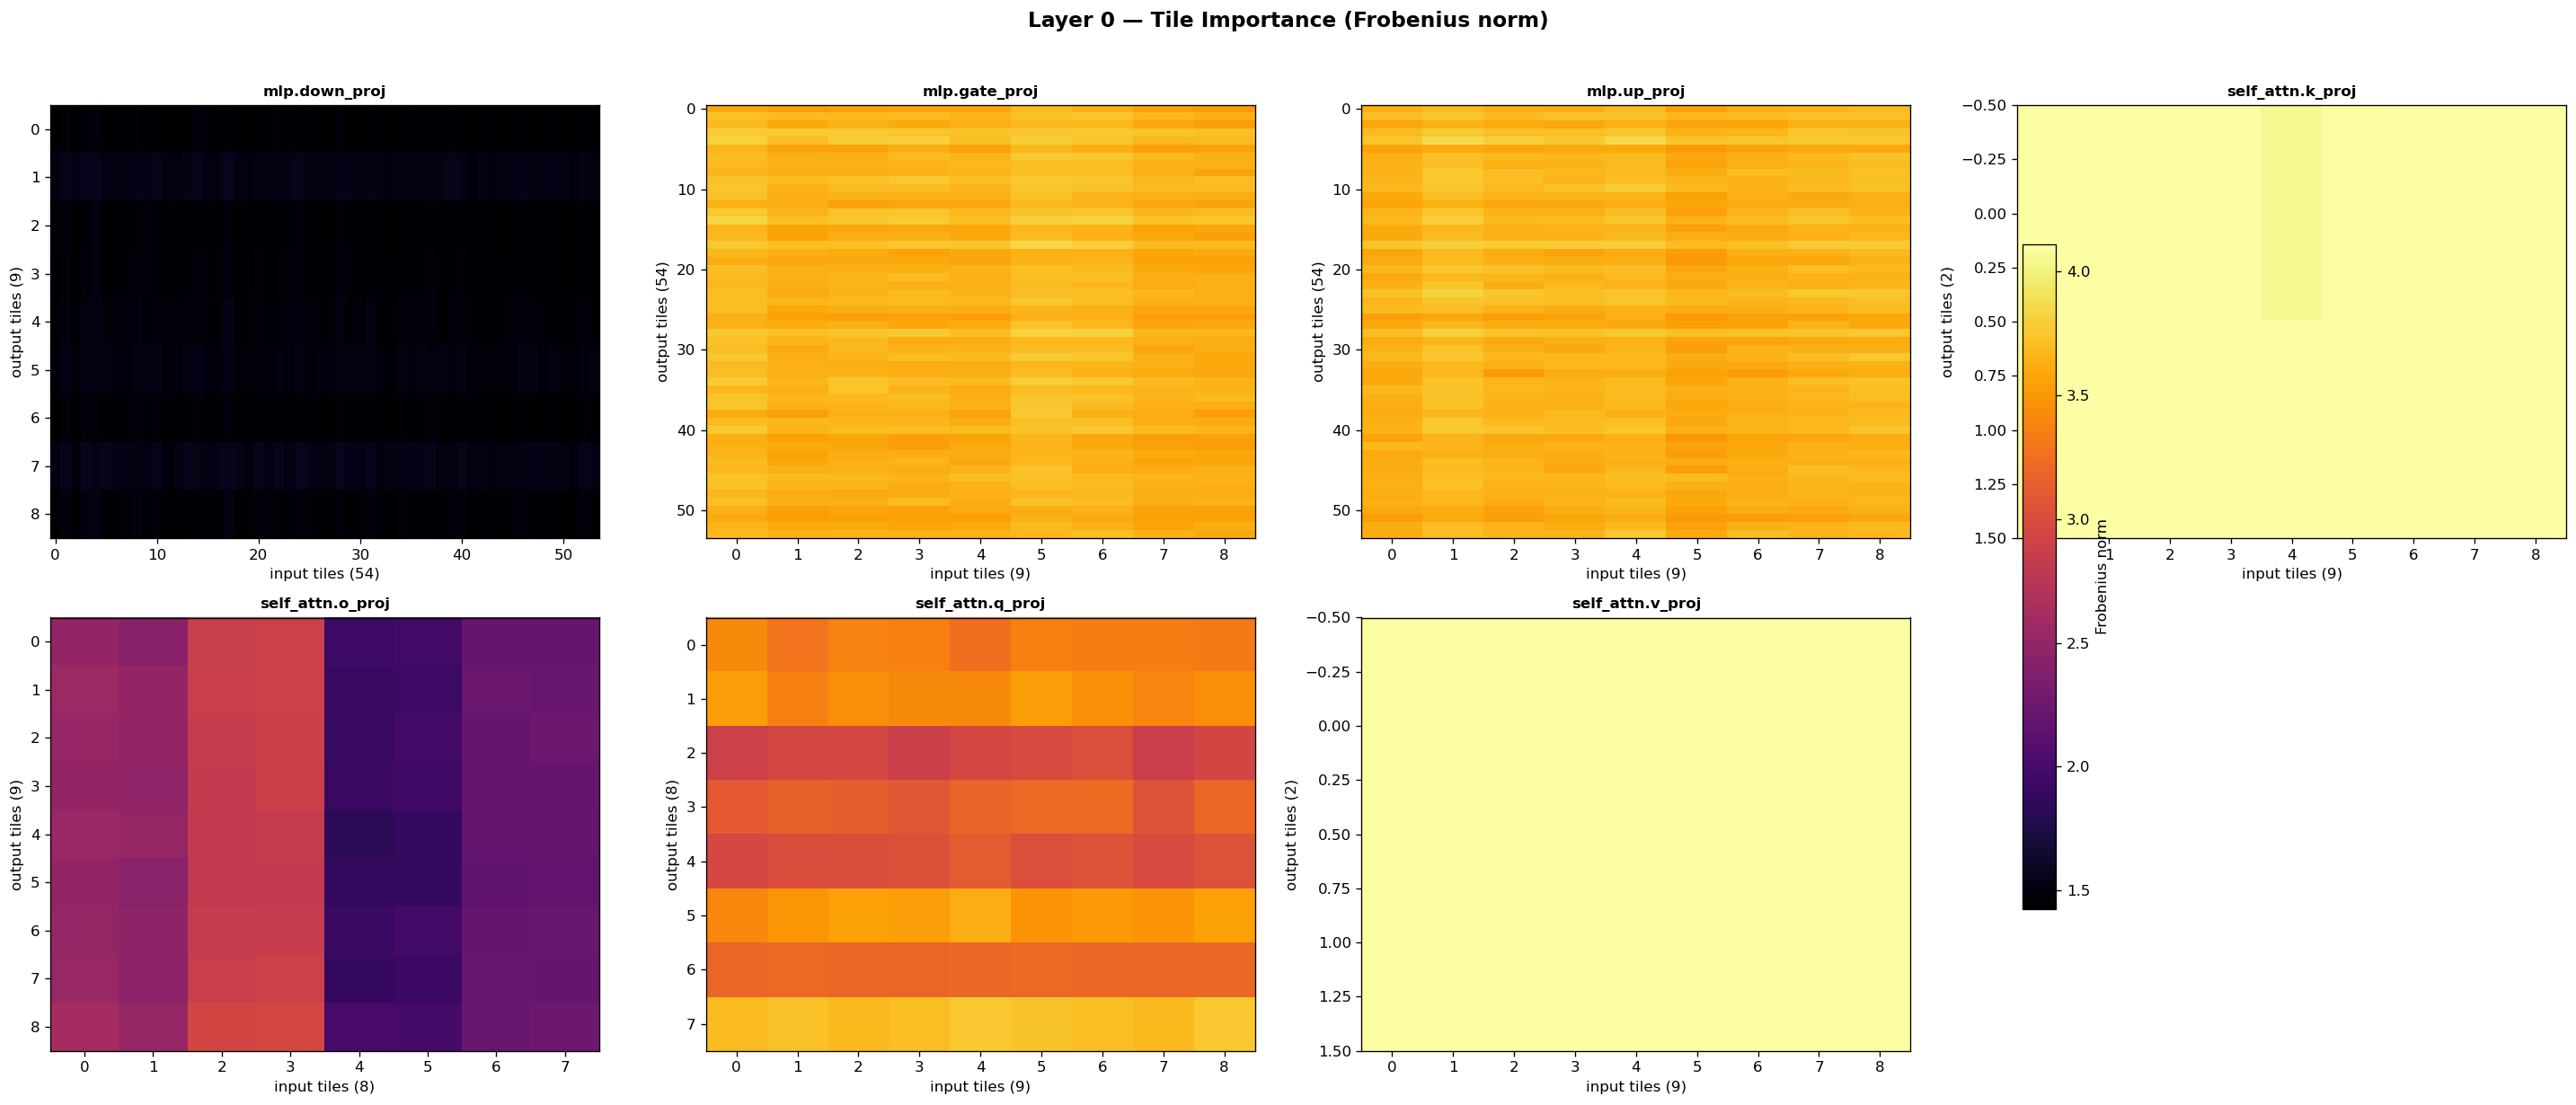

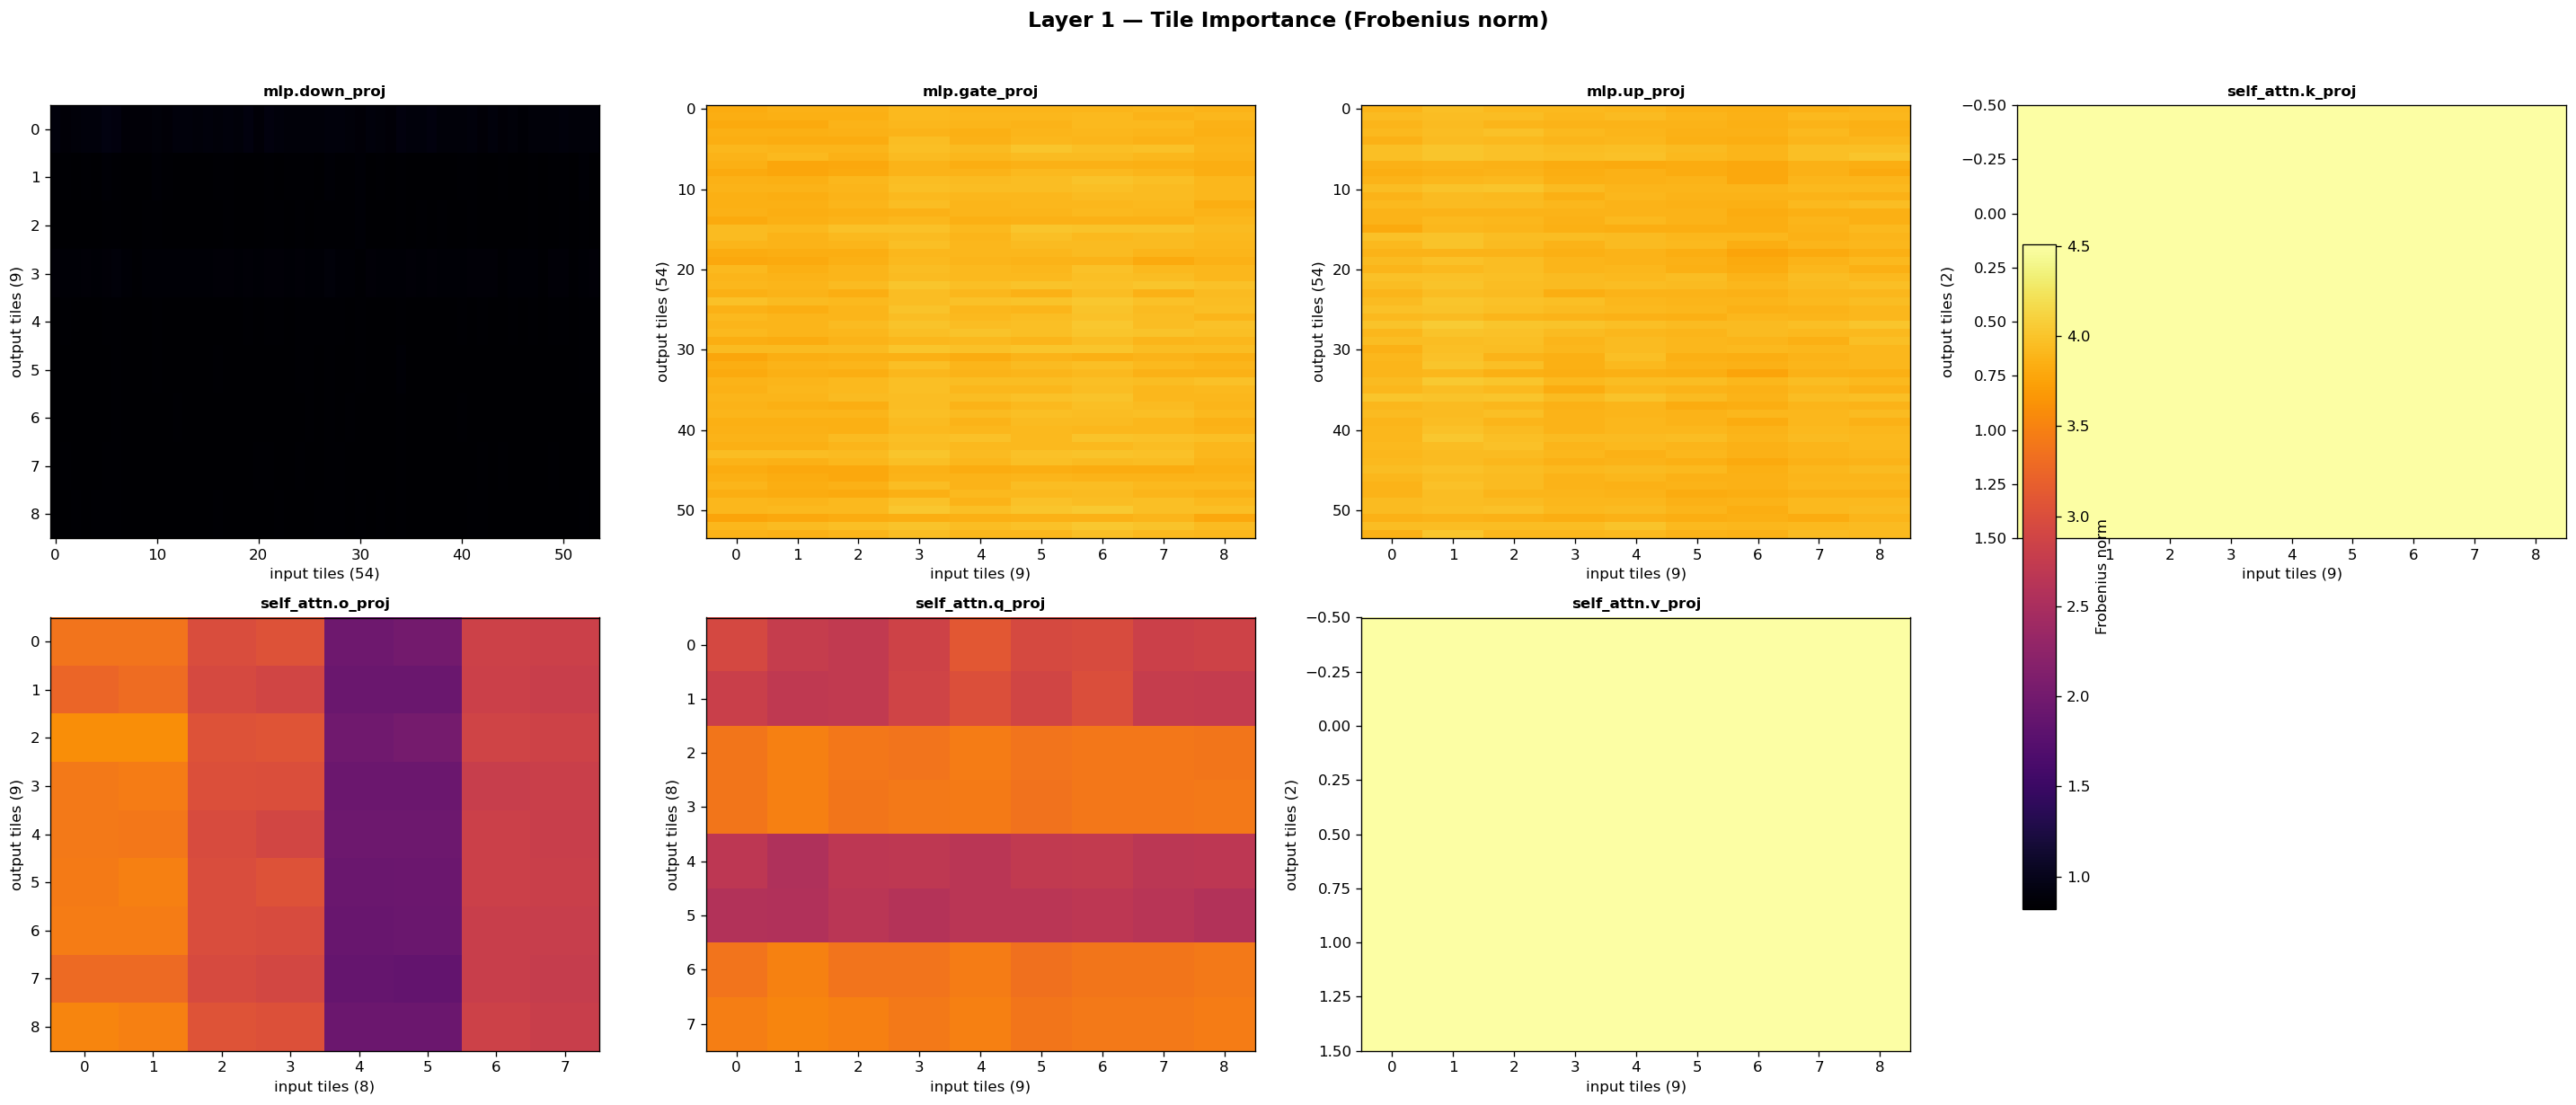

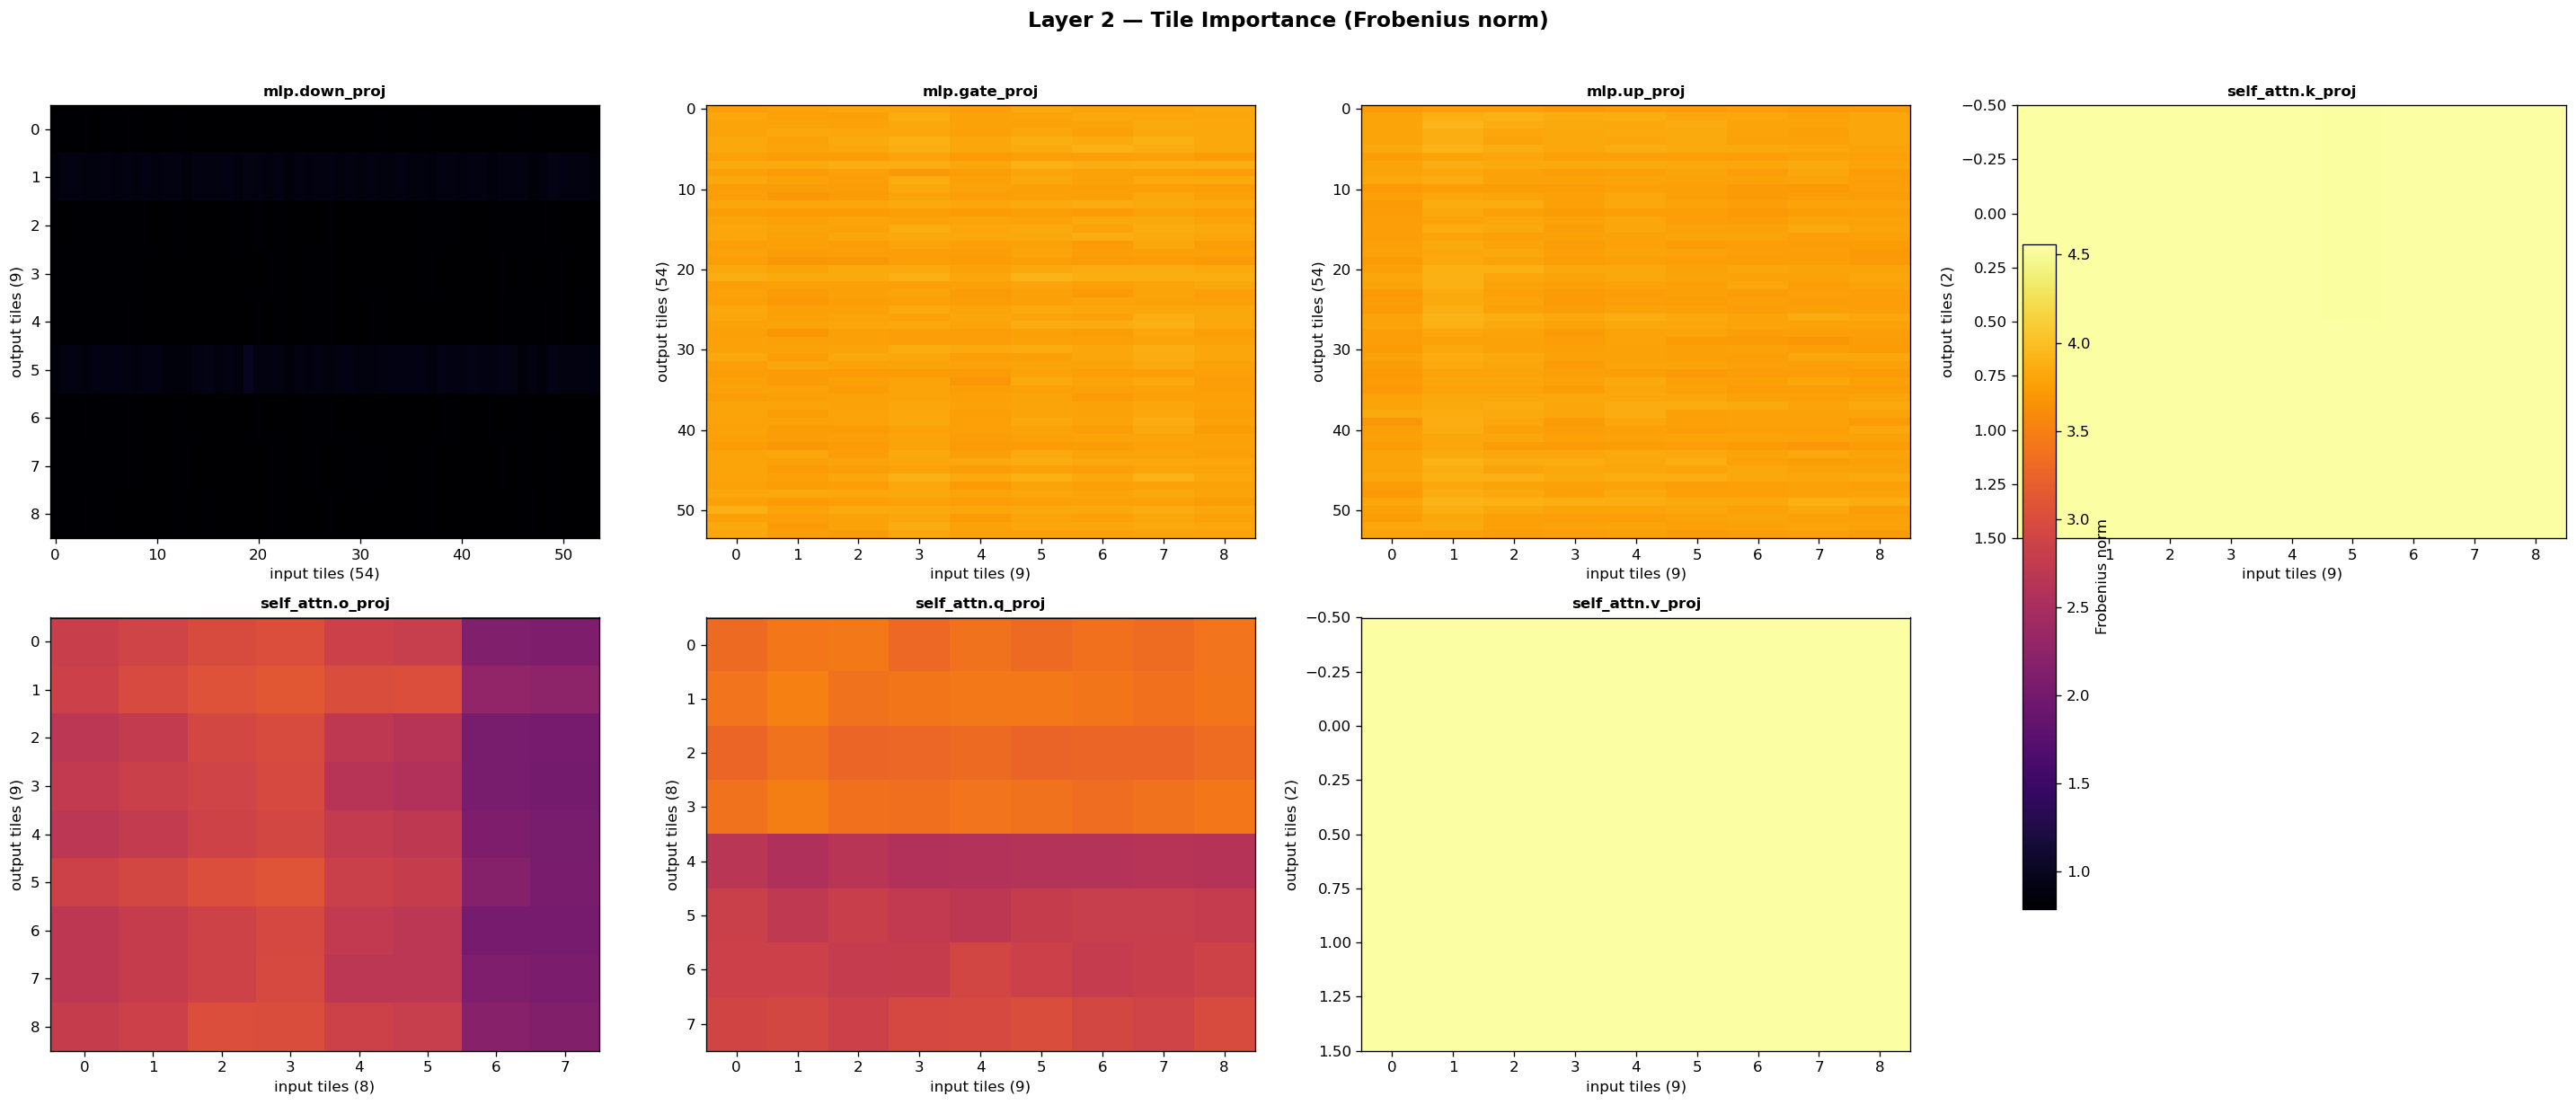

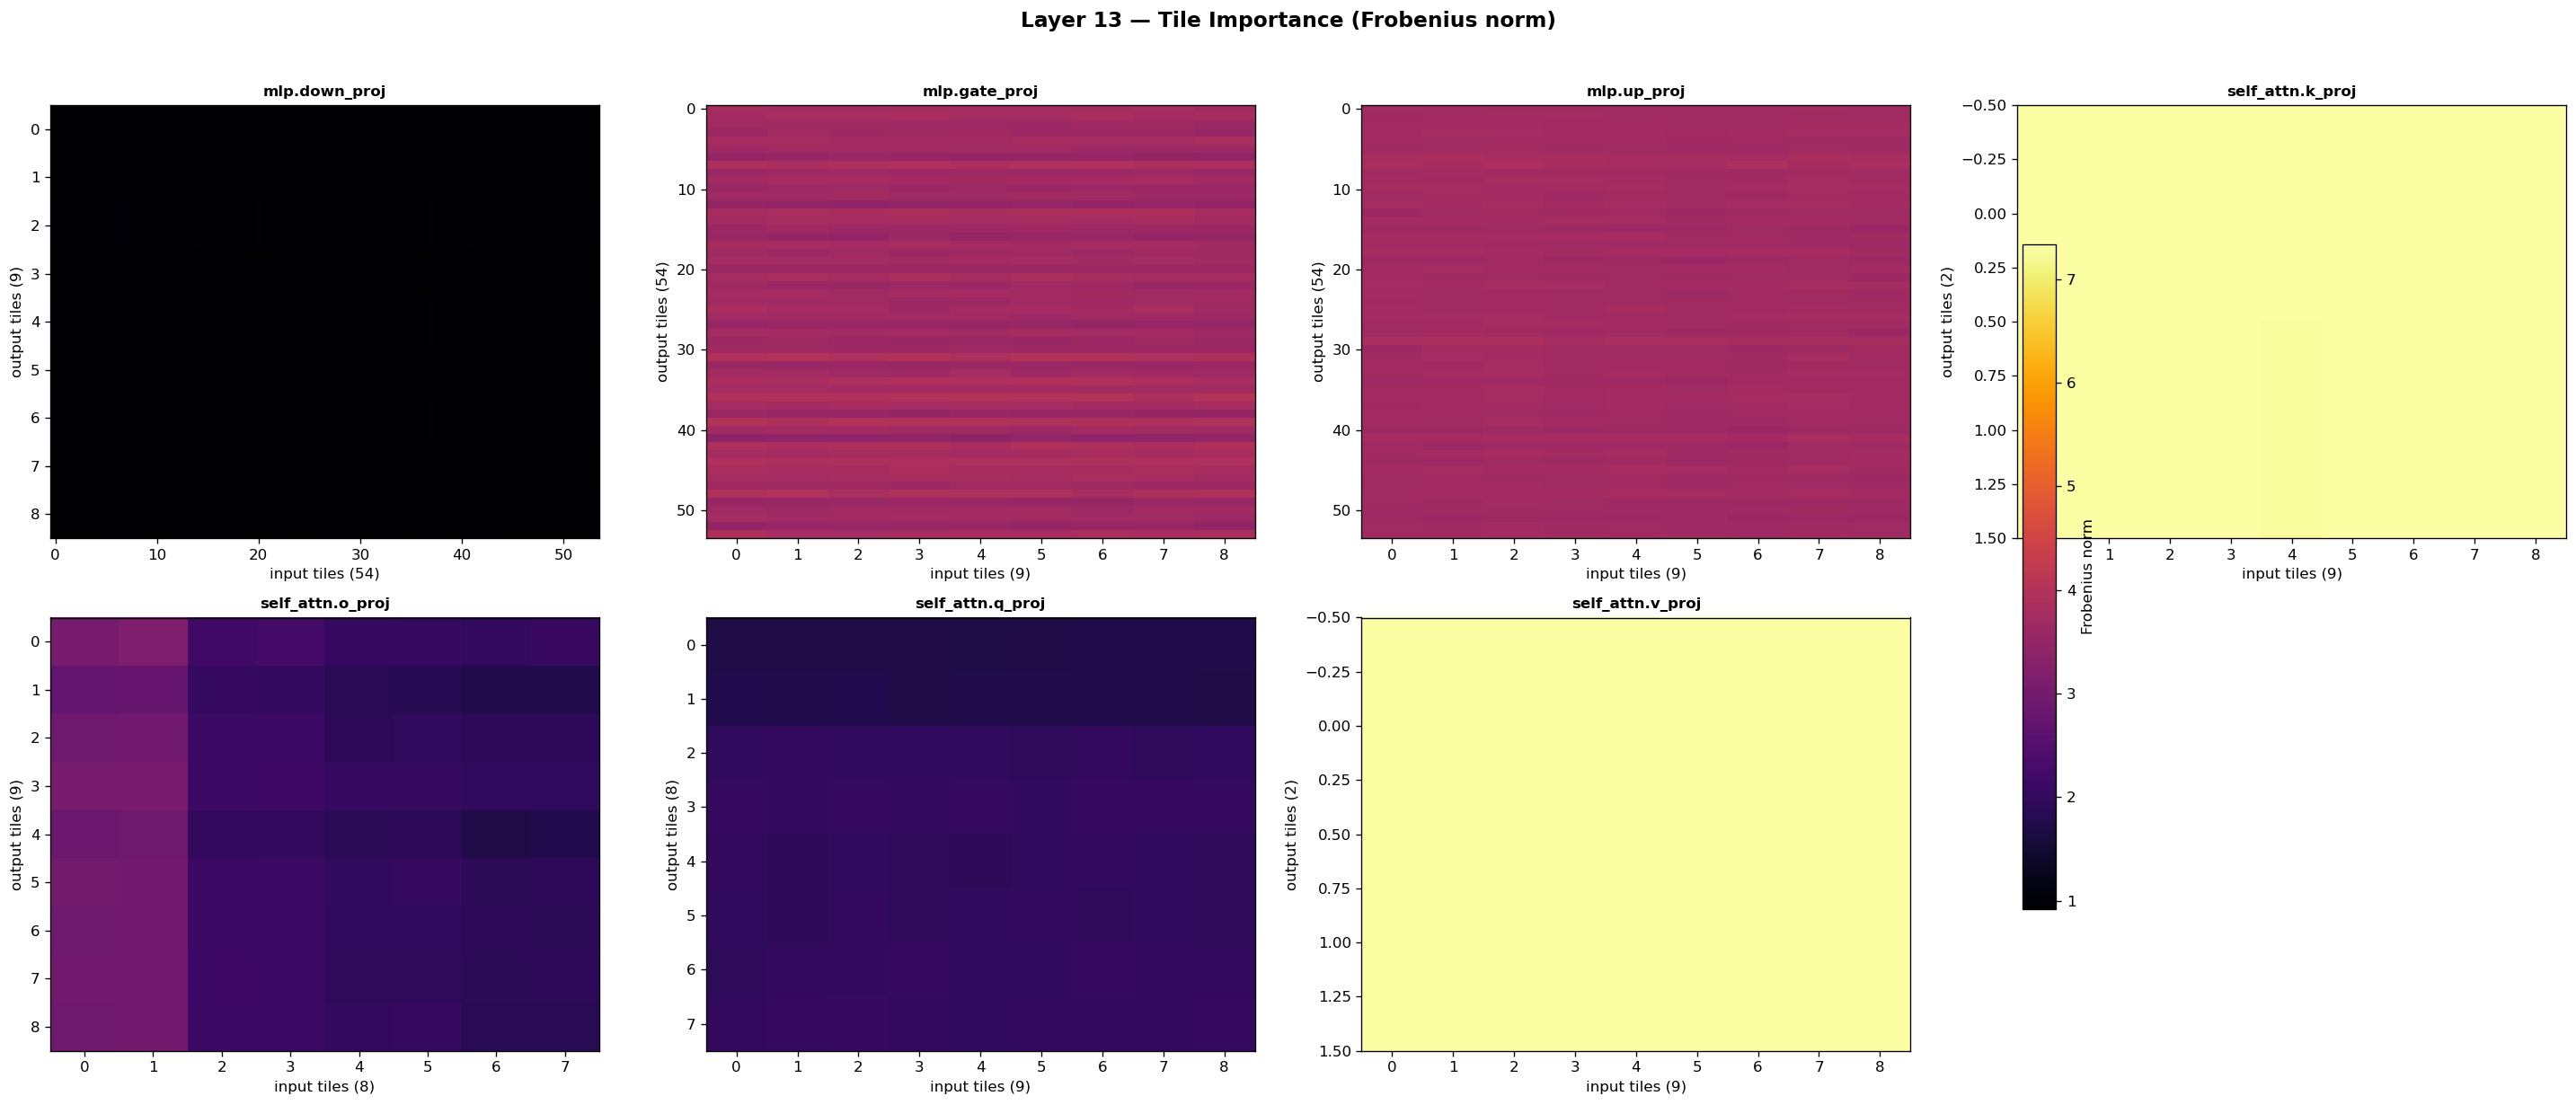

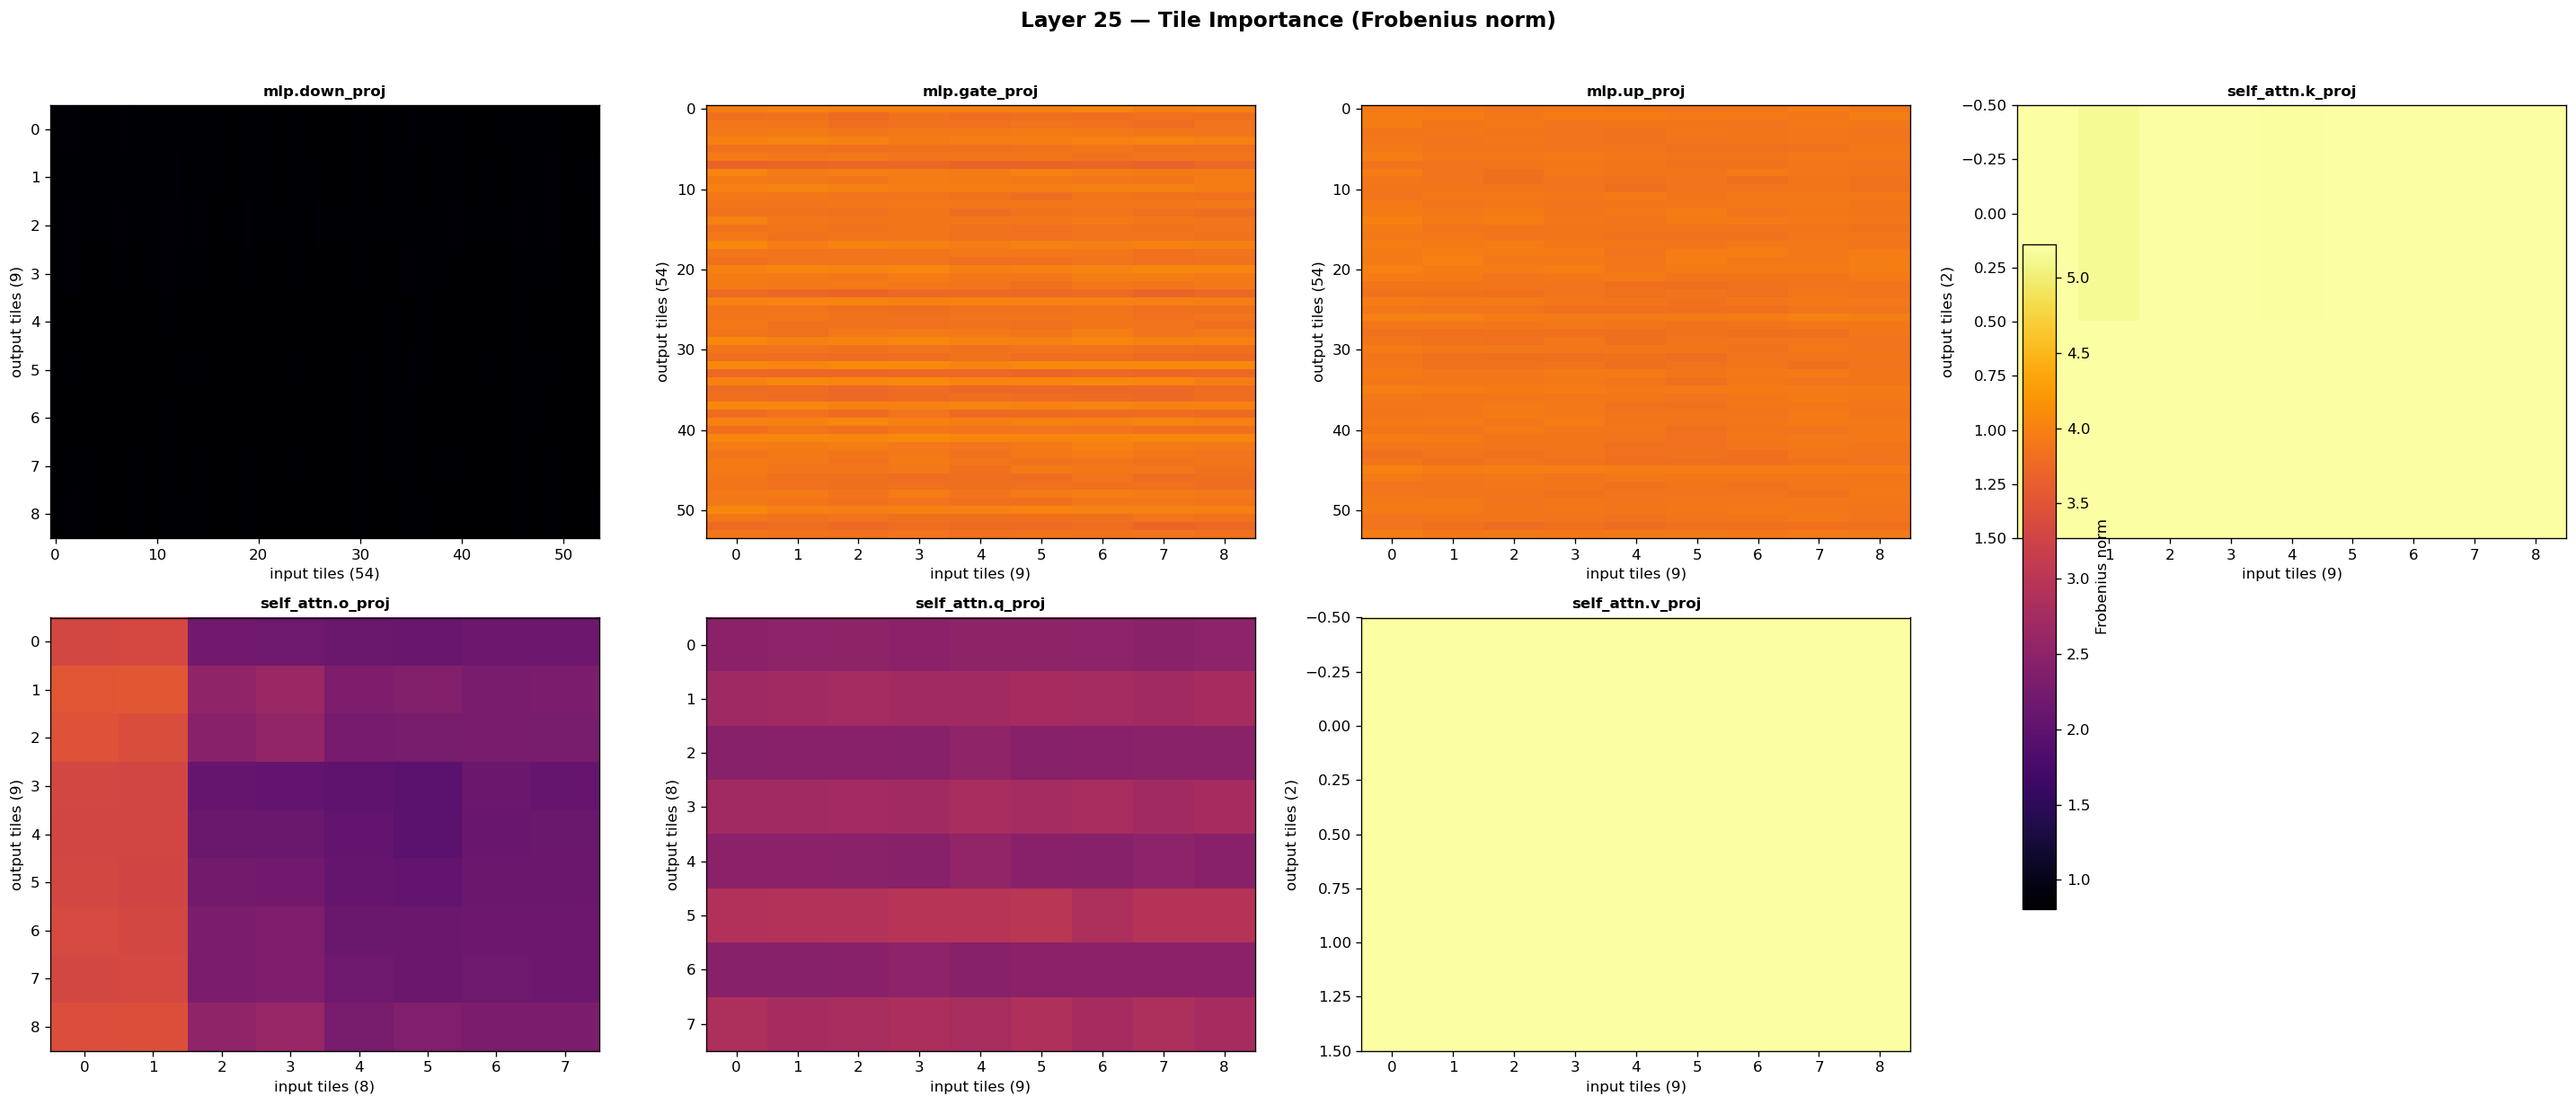

In [6]:
def plot_layer_heatmaps(layer_idx: int, components: dict):
    """Plot spatial heatmaps for all weight matrices in a single layer, using a grid layout."""
    n = len(components)
    ncols = min(4, n)
    nrows = (n + ncols - 1) // ncols
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
    axes = np.atleast_2d(axes)
    axes_flat = axes.ravel()
    
    # Hide unused axes
    for ax in axes_flat[n:]:
        ax.set_visible(False)
    
    # Shared color scale
    all_vals = np.concatenate([m.ravel() for m in components.values()])
    vmin, vmax = np.percentile(all_vals, [2, 98])
    
    for ax, (comp_name, imp_map) in zip(axes_flat, sorted(components.items())):
        im = ax.imshow(
            imp_map,
            aspect="auto",
            cmap="inferno",
            vmin=vmin,
            vmax=vmax,
            interpolation="nearest",
        )
        ax.set_title(comp_name, fontsize=10, fontweight="bold")
        ax.set_xlabel(f"input tiles ({imp_map.shape[1]})")
        ax.set_ylabel(f"output tiles ({imp_map.shape[0]})")
    
    fig.suptitle(f"Layer {layer_idx} — Tile Importance (Frobenius norm)", fontsize=14, fontweight="bold", y=1.02)
    fig.colorbar(im, ax=axes_flat[:n].tolist(), shrink=0.8, label="Frobenius norm", pad=0.02)
    plt.tight_layout()
    plt.show()

# Show first 3 layers, a middle layer, and the last layer
sample_layers = [0, 1, 2, n_layers // 2, n_layers - 1]
for li in sample_layers:
    if li in layer_components:
        plot_layer_heatmaps(li, layer_components[li])

## 5. Full-model overview — all layers, all components

A single large heatmap where each row is a layer and each column is a component type. The cell color is the **mean tile importance** for that weight matrix. This gives you the bird's-eye view of which layers/components are hot vs. cold.

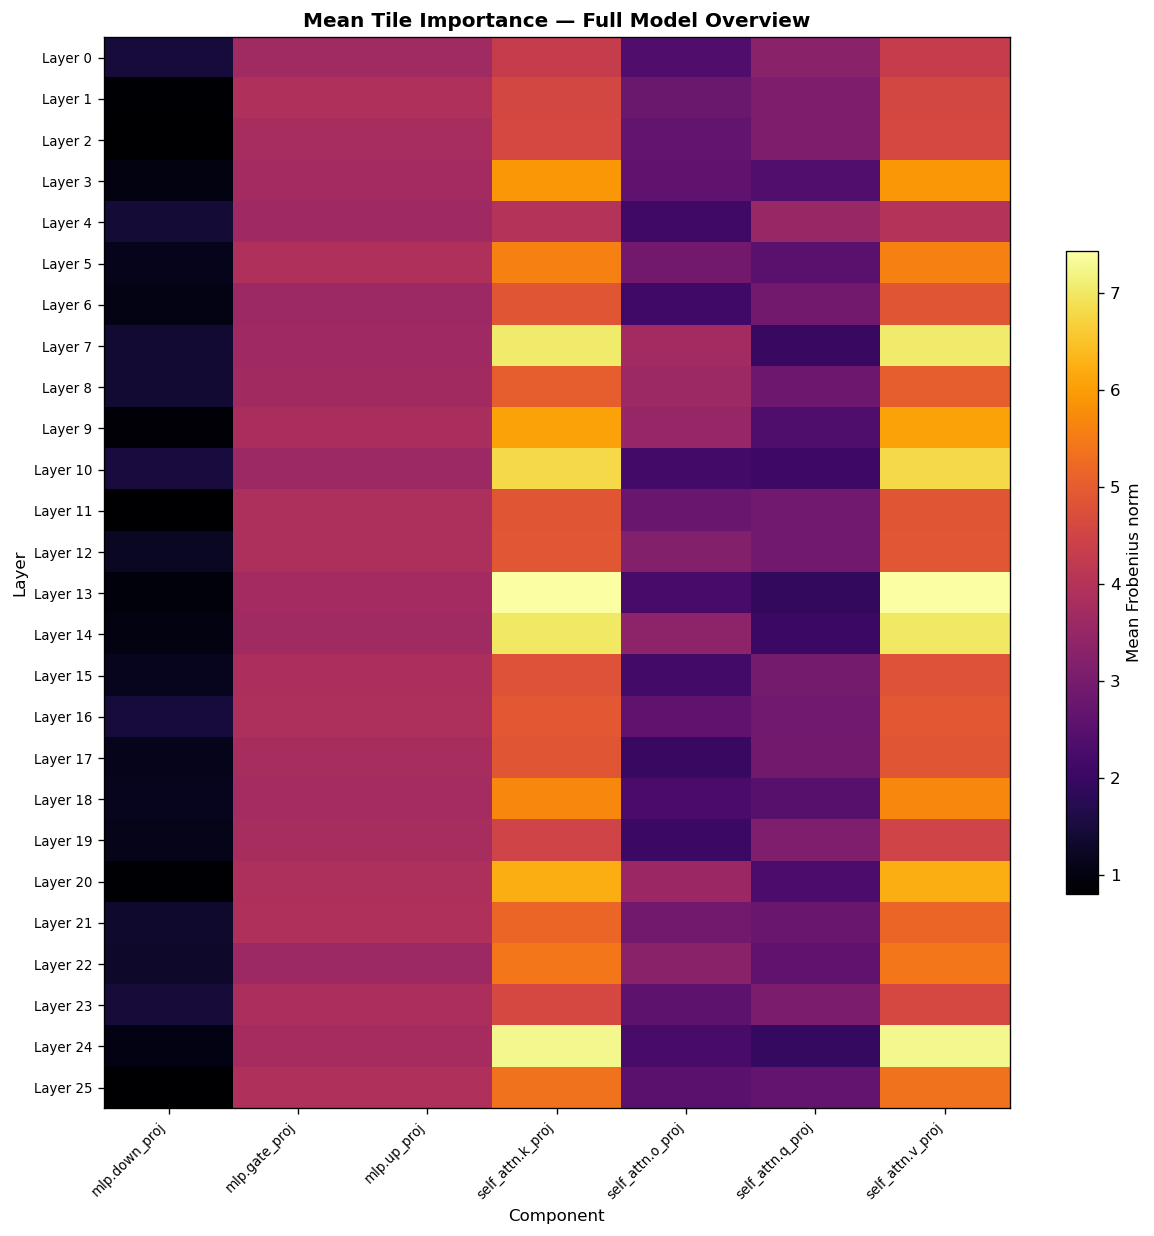

In [7]:
# Build the overview matrix: rows = layers, cols = component types
all_comp_names = sorted(set(c for comps in layer_components.values() for c in comps))
overview = np.zeros((n_layers, len(all_comp_names)))

for li in range(n_layers):
    for ci, comp_name in enumerate(all_comp_names):
        if comp_name in layer_components[li]:
            overview[li, ci] = layer_components[li][comp_name].mean()

fig, ax = plt.subplots(figsize=(max(8, len(all_comp_names) * 1.5), max(8, n_layers * 0.4)))
im = ax.imshow(overview, aspect="auto", cmap="inferno", interpolation="nearest")

ax.set_xticks(range(len(all_comp_names)))
ax.set_xticklabels(all_comp_names, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(n_layers))
ax.set_yticklabels([f"Layer {i}" for i in range(n_layers)], fontsize=8)
ax.set_xlabel("Component")
ax.set_ylabel("Layer")
ax.set_title("Mean Tile Importance — Full Model Overview", fontweight="bold")
fig.colorbar(im, ax=ax, shrink=0.6, label="Mean Frobenius norm")
plt.tight_layout()
plt.show()

## 6. Pruning candidate map (MLP only)

For a given pruning target (e.g. 30%), which MLP tiles would get pruned? Attention projections are excluded from pruning — they stay untouched.

> **Note:** Attention pruning is left for a future experiment. Q/K/V/O projections are tightly coupled, and tile-pruning them risks breaking head alignment in unpredictable ways.

In [8]:
PRUNE_RATIO = 0.30  # change this to explore different targets

def compute_global_threshold(maps: dict, ratio: float) -> float:
    """Compute the global importance threshold for a given pruning ratio."""
    all_scores = np.concatenate([m.ravel() for m in maps.values()])
    return float(np.percentile(all_scores, ratio * 100))

# Threshold computed from NORMALIZED MLP scores
threshold = compute_global_threshold(importance_maps_mlp_norm, PRUNE_RATIO)
print(f"Pruning ratio: {PRUNE_RATIO*100:.0f}% (MLP only, normalized scores)")
print(f"Global normalized threshold: {threshold:.4f}")

total_tiles = sum(m.size for m in importance_maps_mlp_norm.values())
pruned_tiles = sum((m < threshold).sum() for m in importance_maps_mlp_norm.values())
print(f"MLP tiles: {pruned_tiles}/{total_tiles} pruned ({pruned_tiles/total_tiles*100:.1f}%)")

# Verify pruning is balanced across component types
for comp_type in ["gate_proj", "up_proj", "down_proj"]:
    tiles = np.concatenate([m.ravel() for name, m in importance_maps_mlp_norm.items() if comp_type in name])
    pct = (tiles < threshold).mean() * 100
    print(f"  {comp_type}: {pct:.1f}% pruned")

Pruning ratio: 30% (MLP only, normalized scores)
Global normalized threshold: -0.5964
MLP tiles: 11373/37908 pruned (30.0%)
  gate_proj: 28.9% pruned
  up_proj: 30.5% pruned
  down_proj: 30.6% pruned


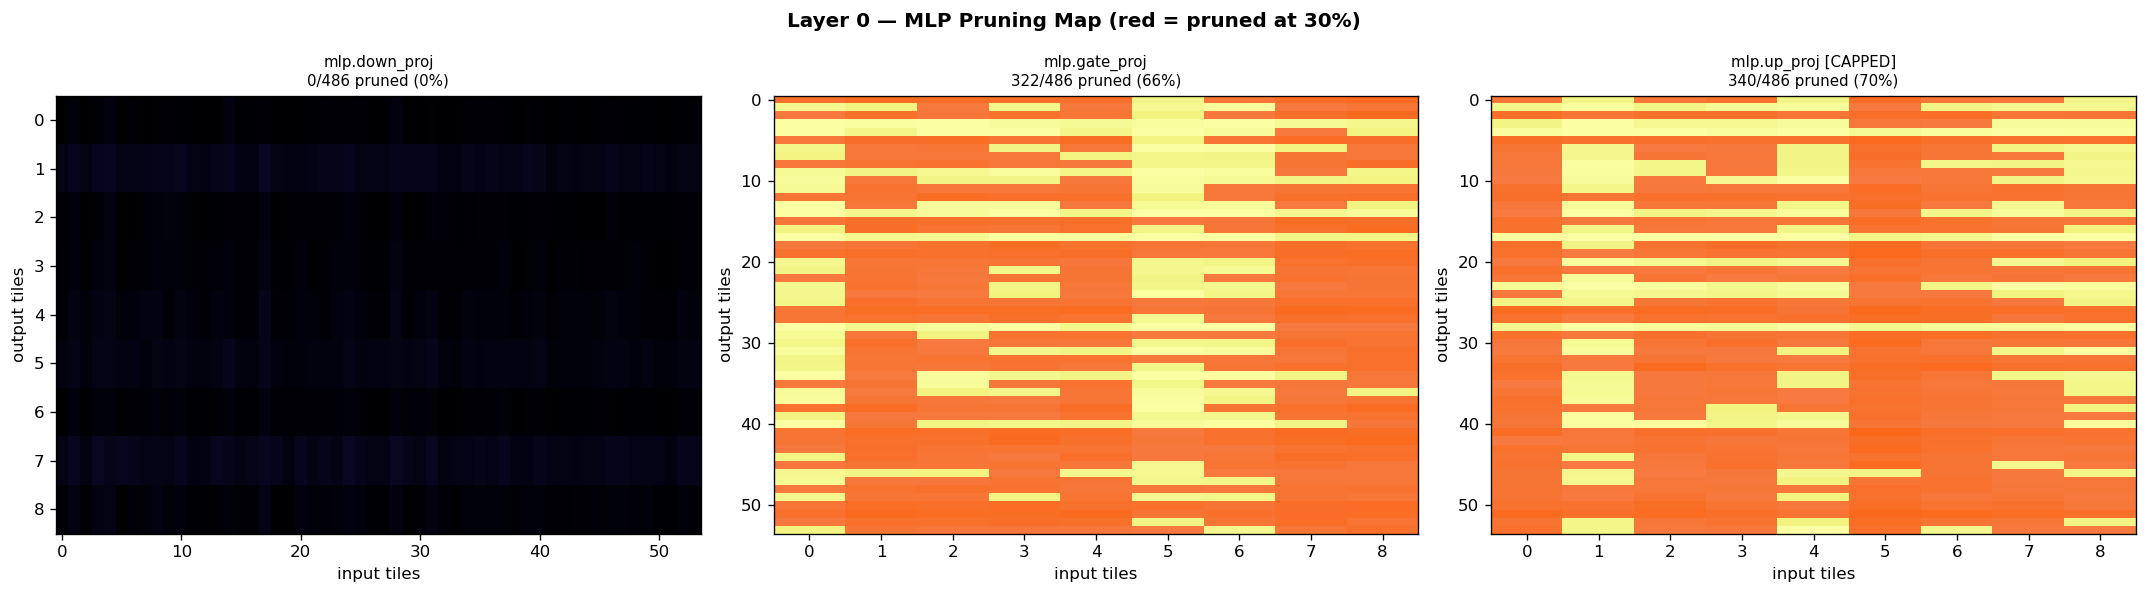

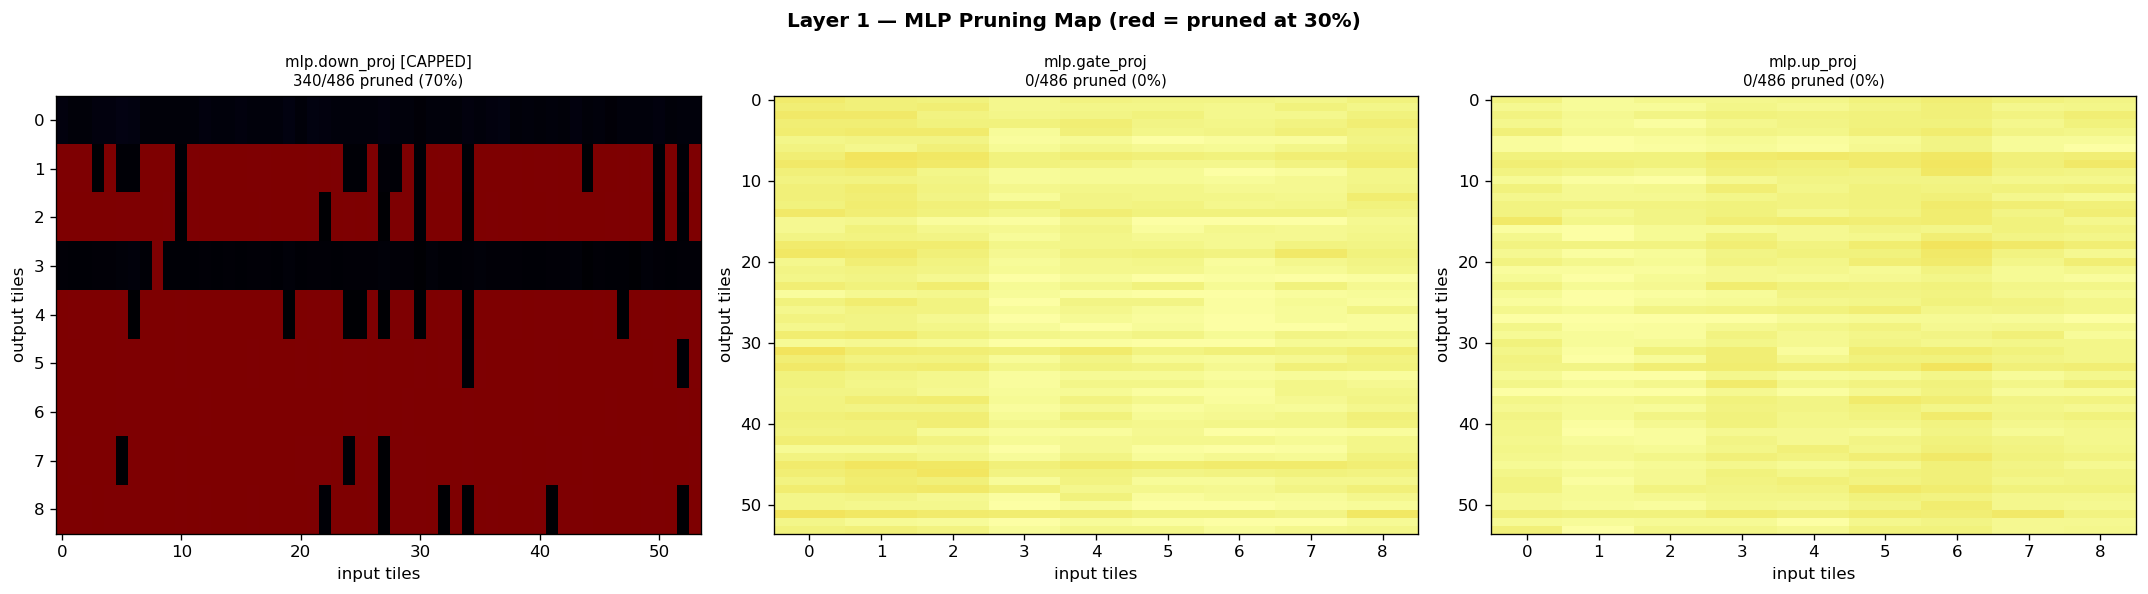

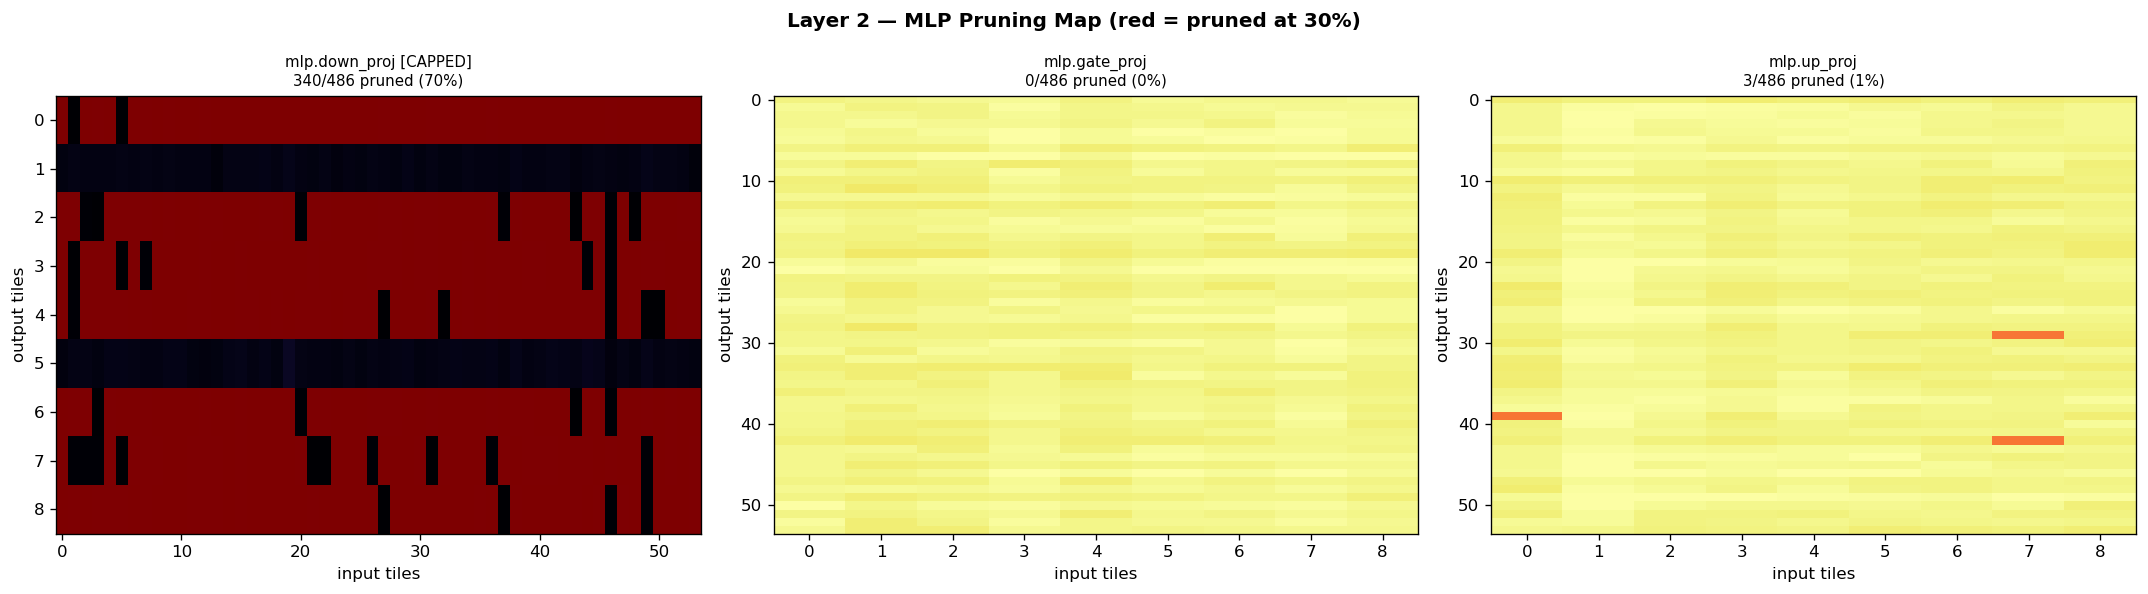

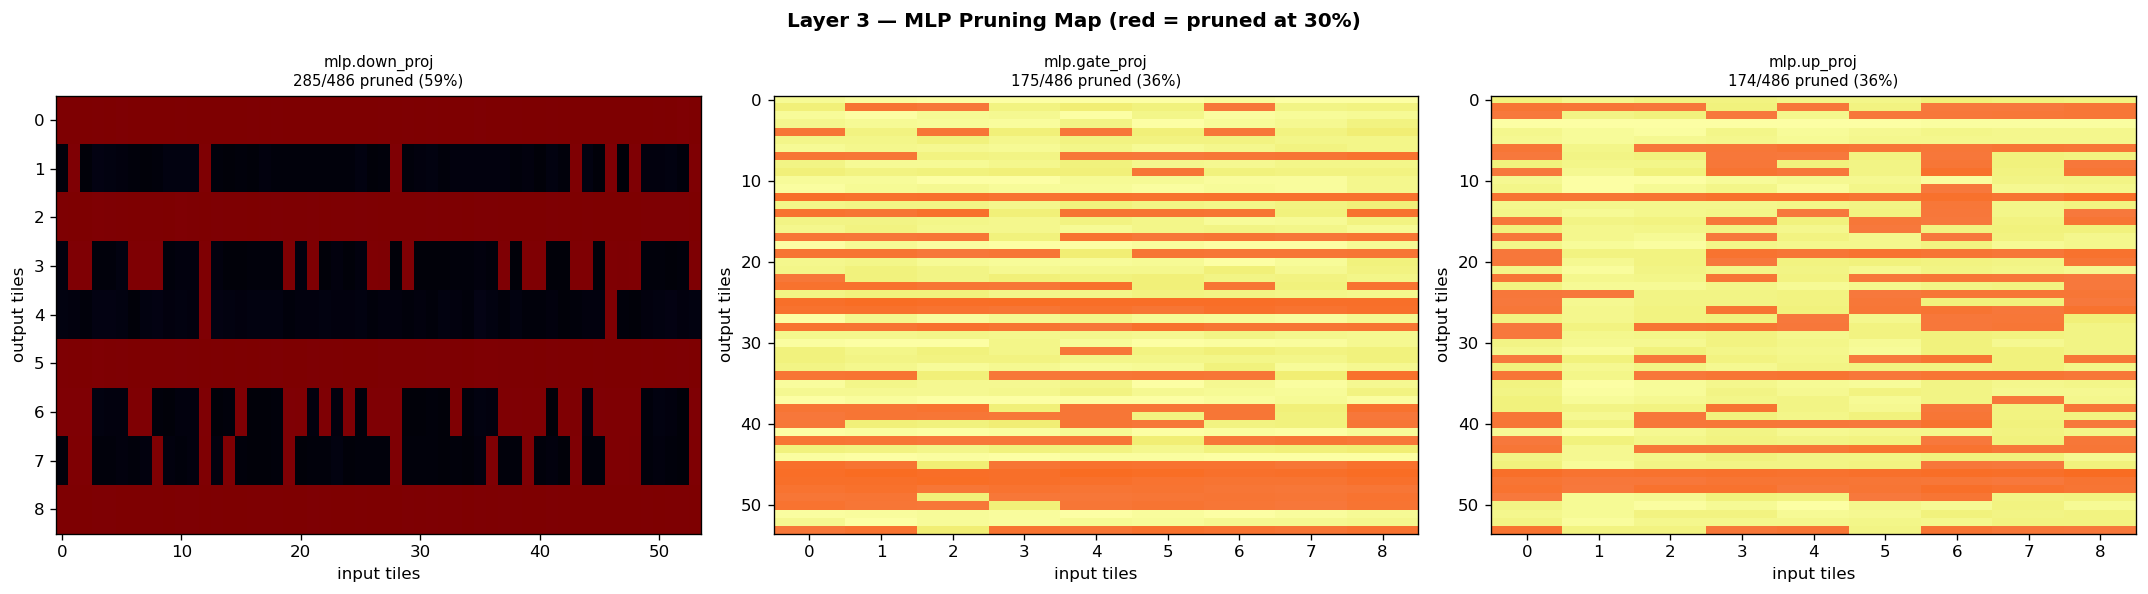

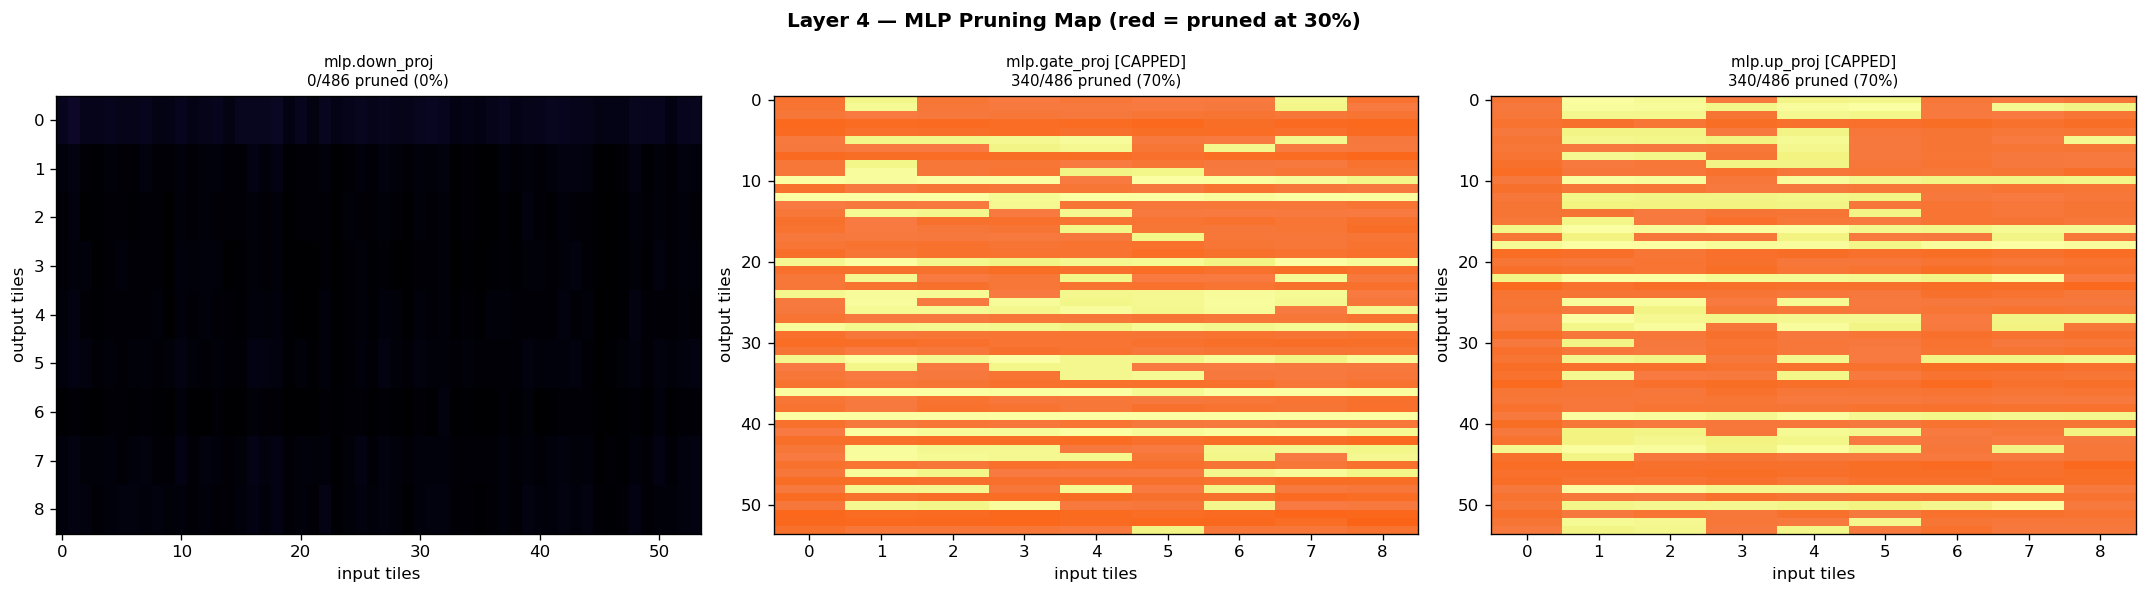

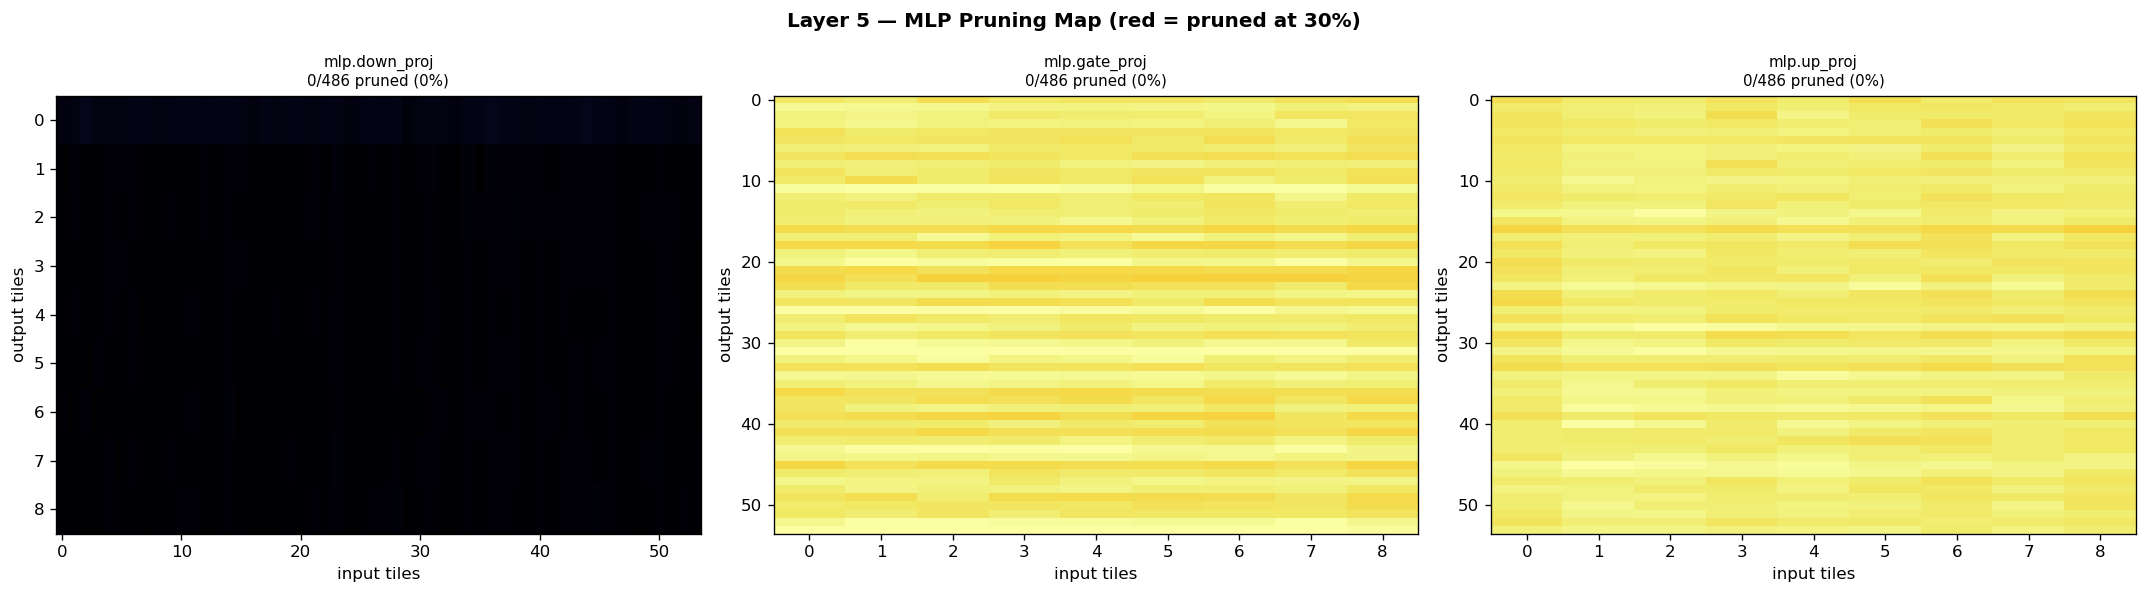

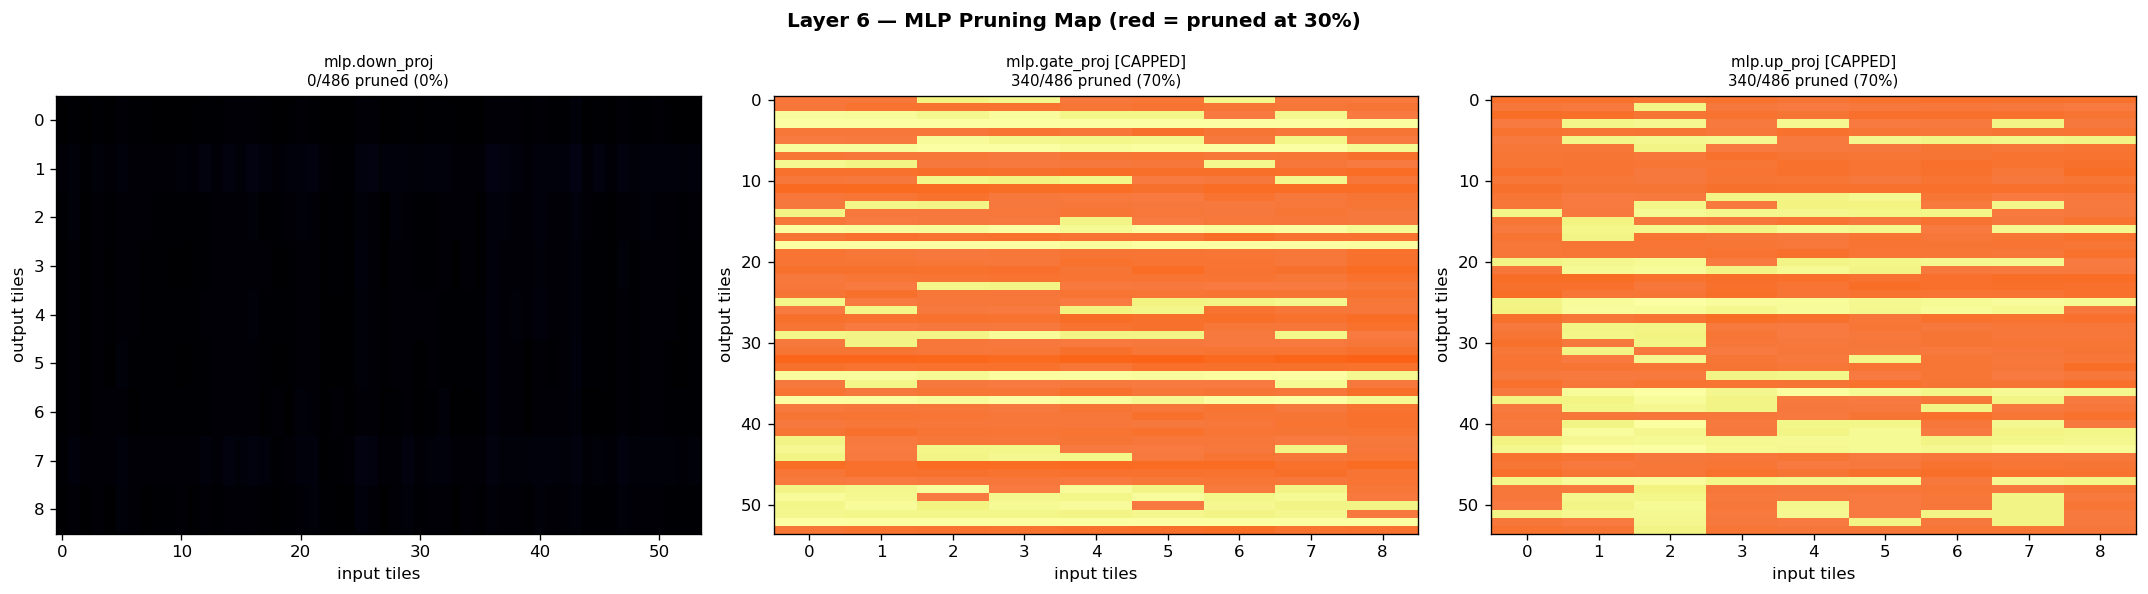

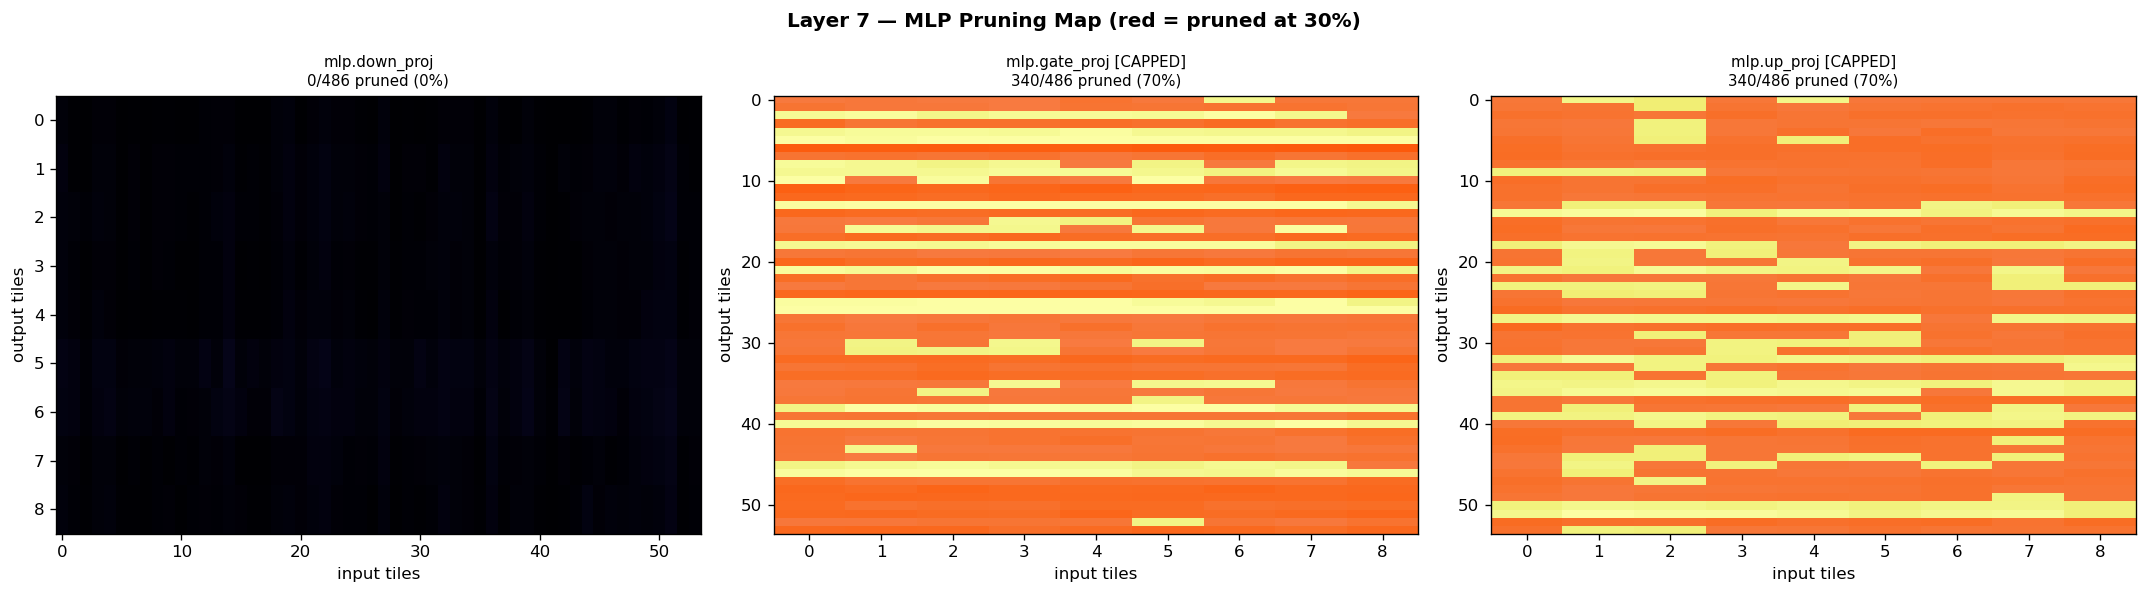

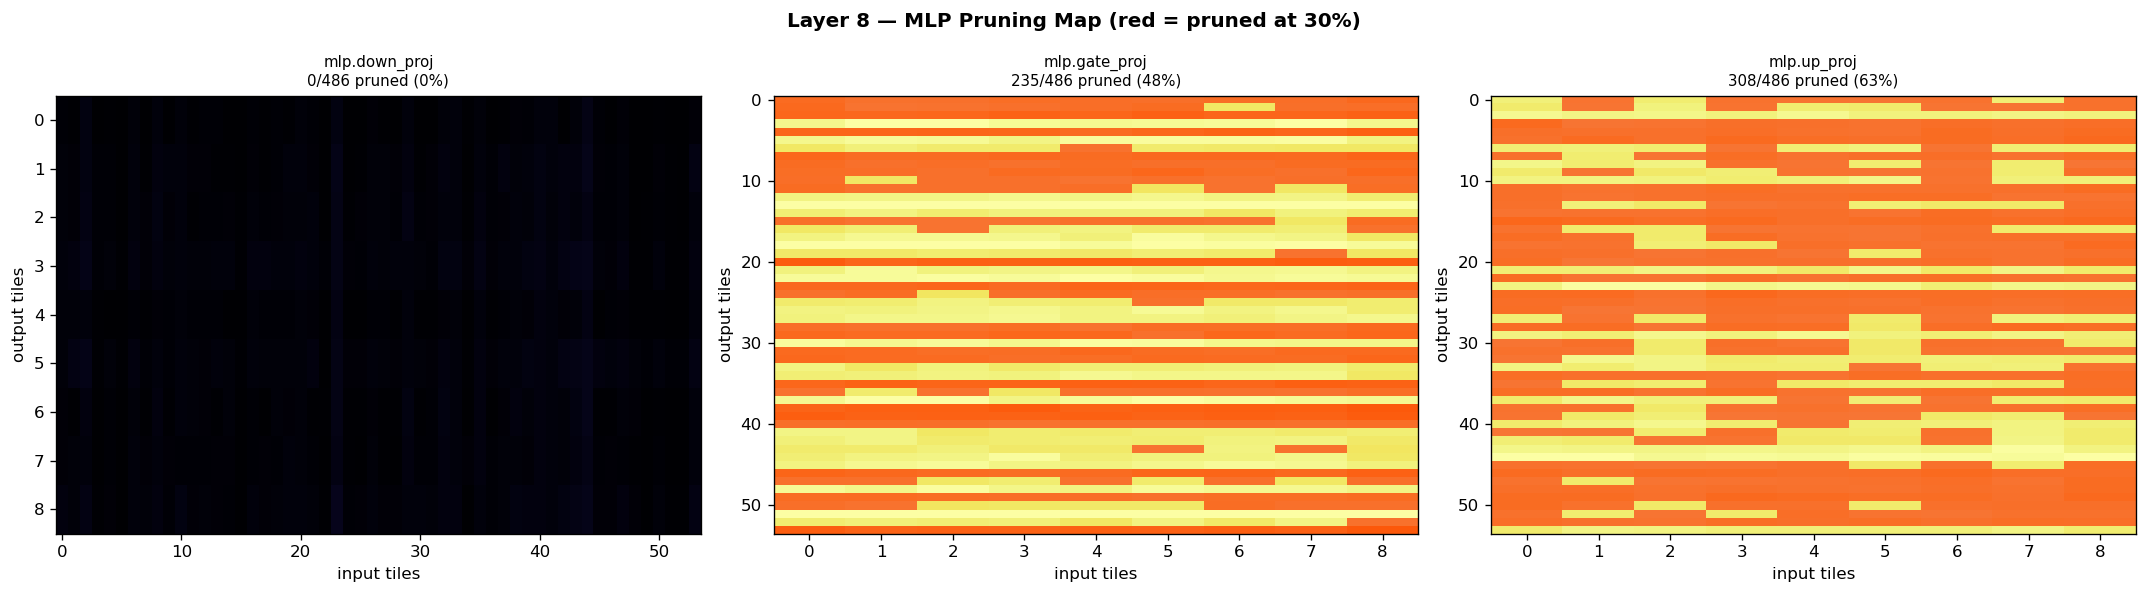

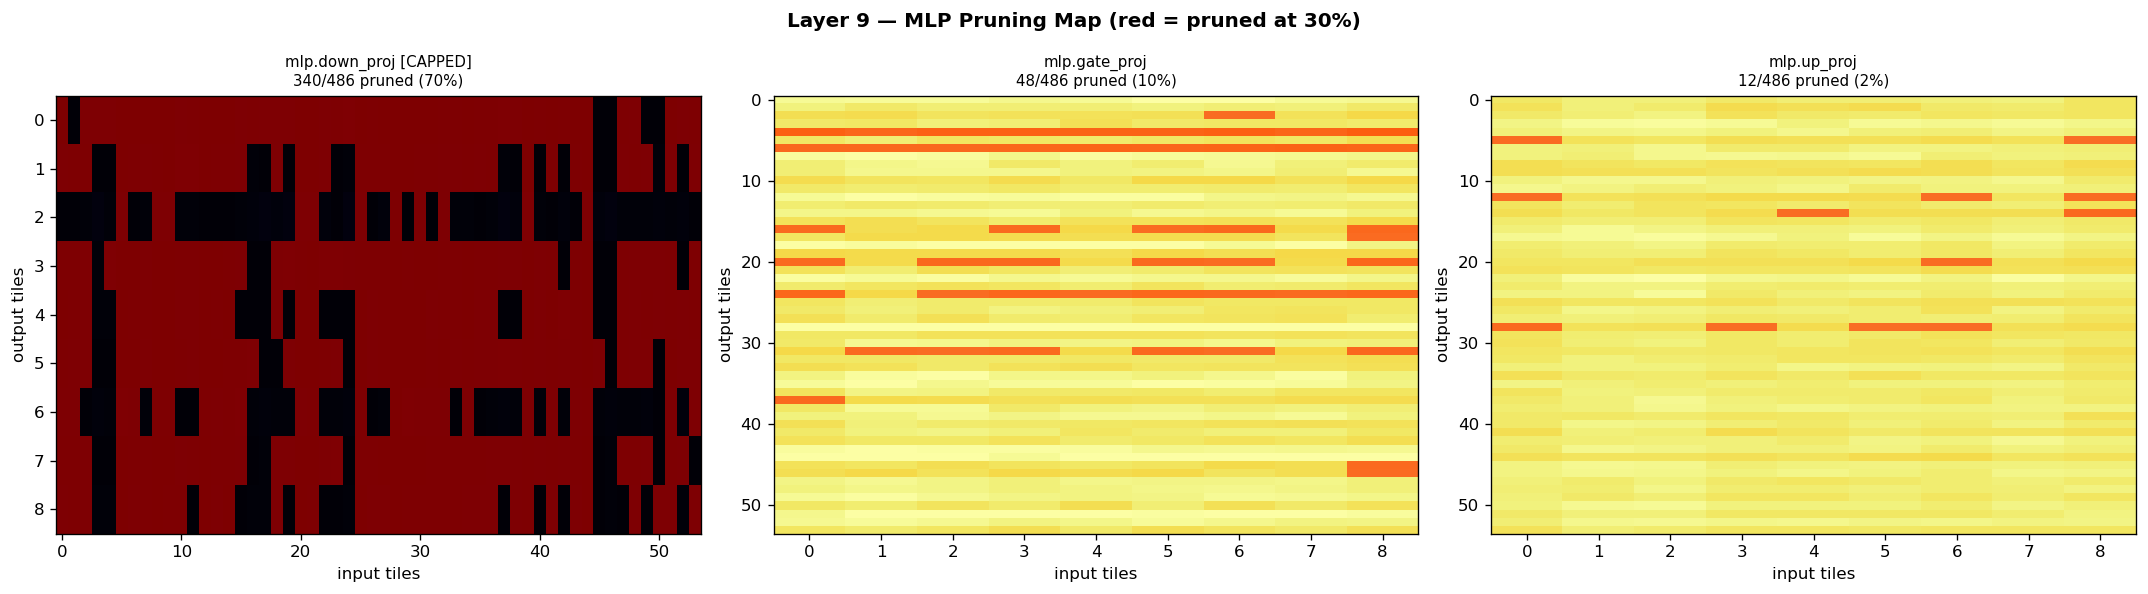

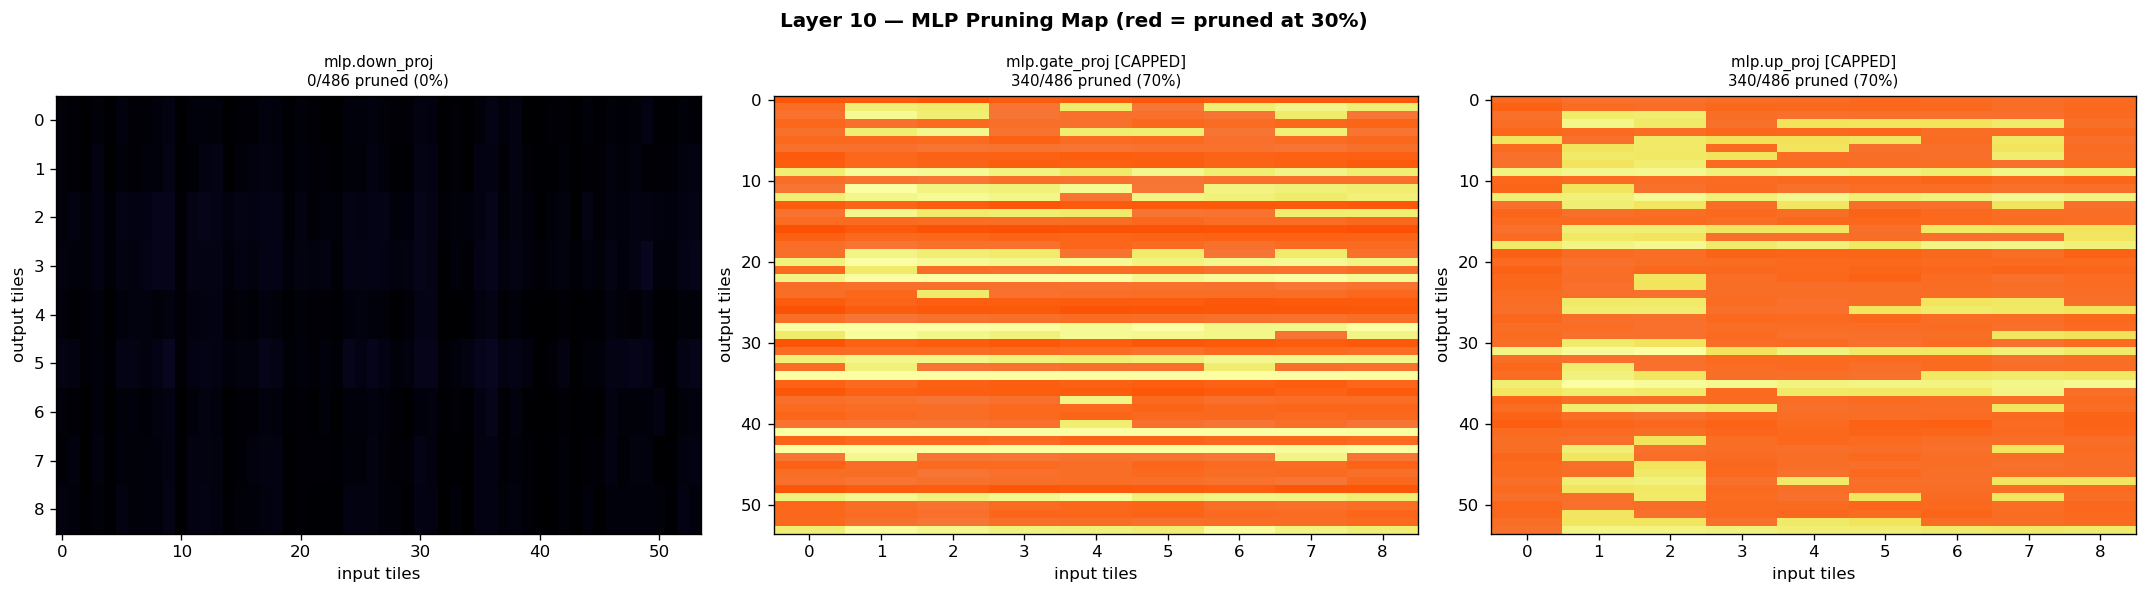

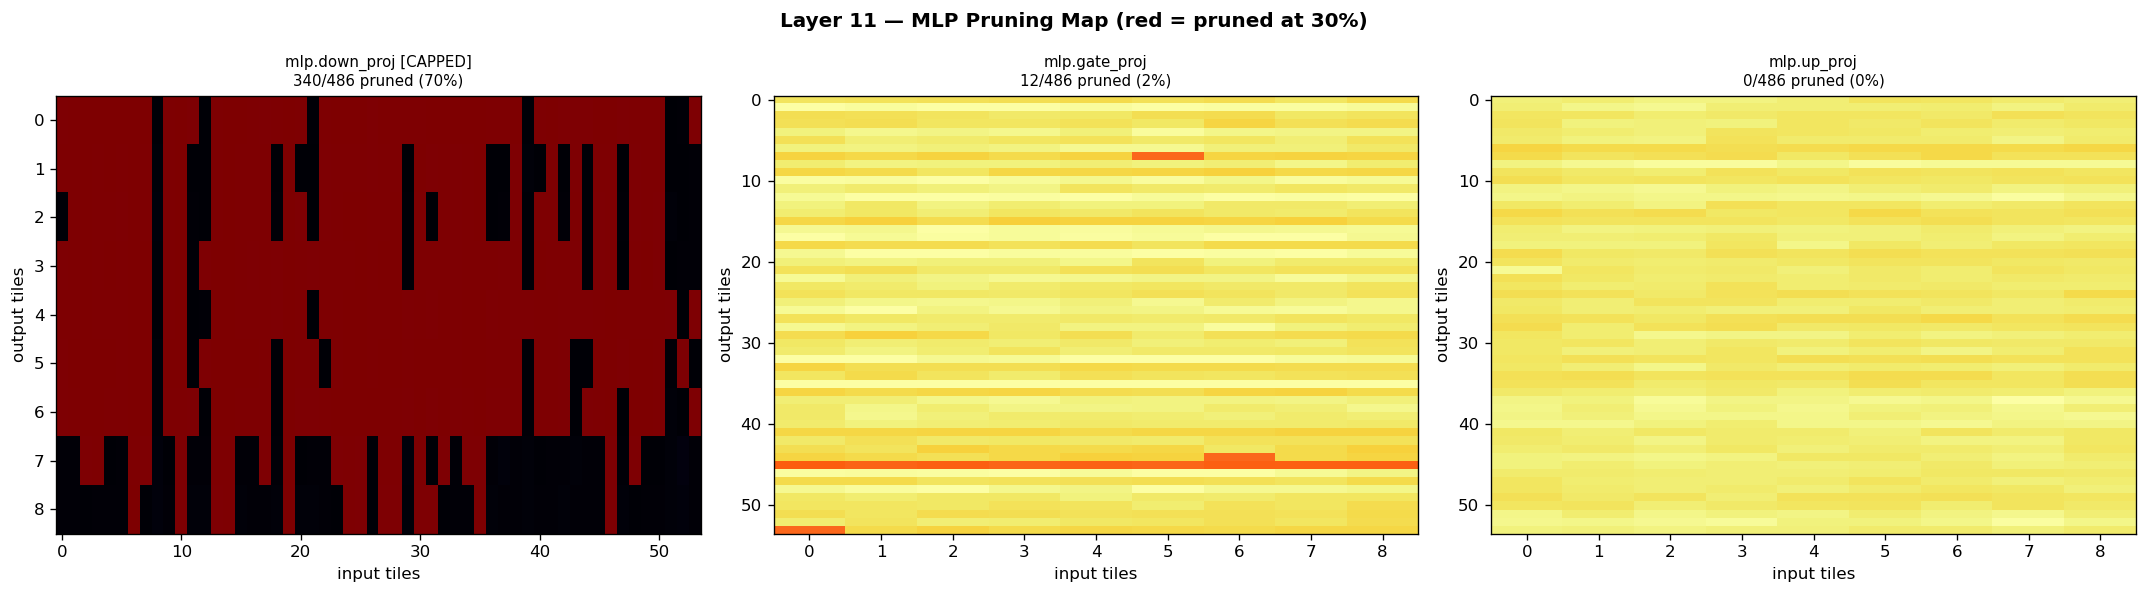

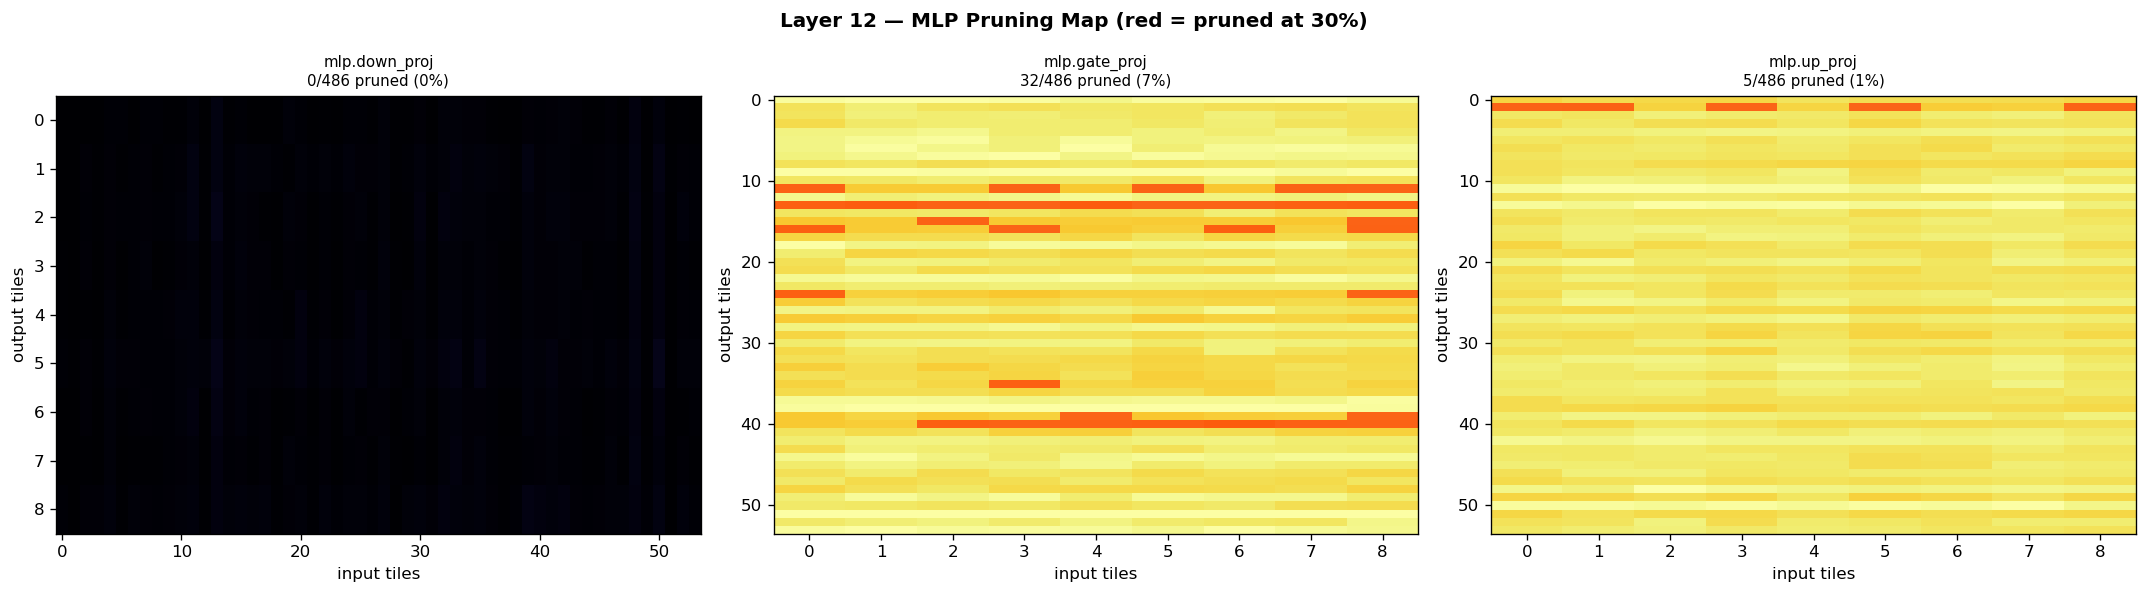

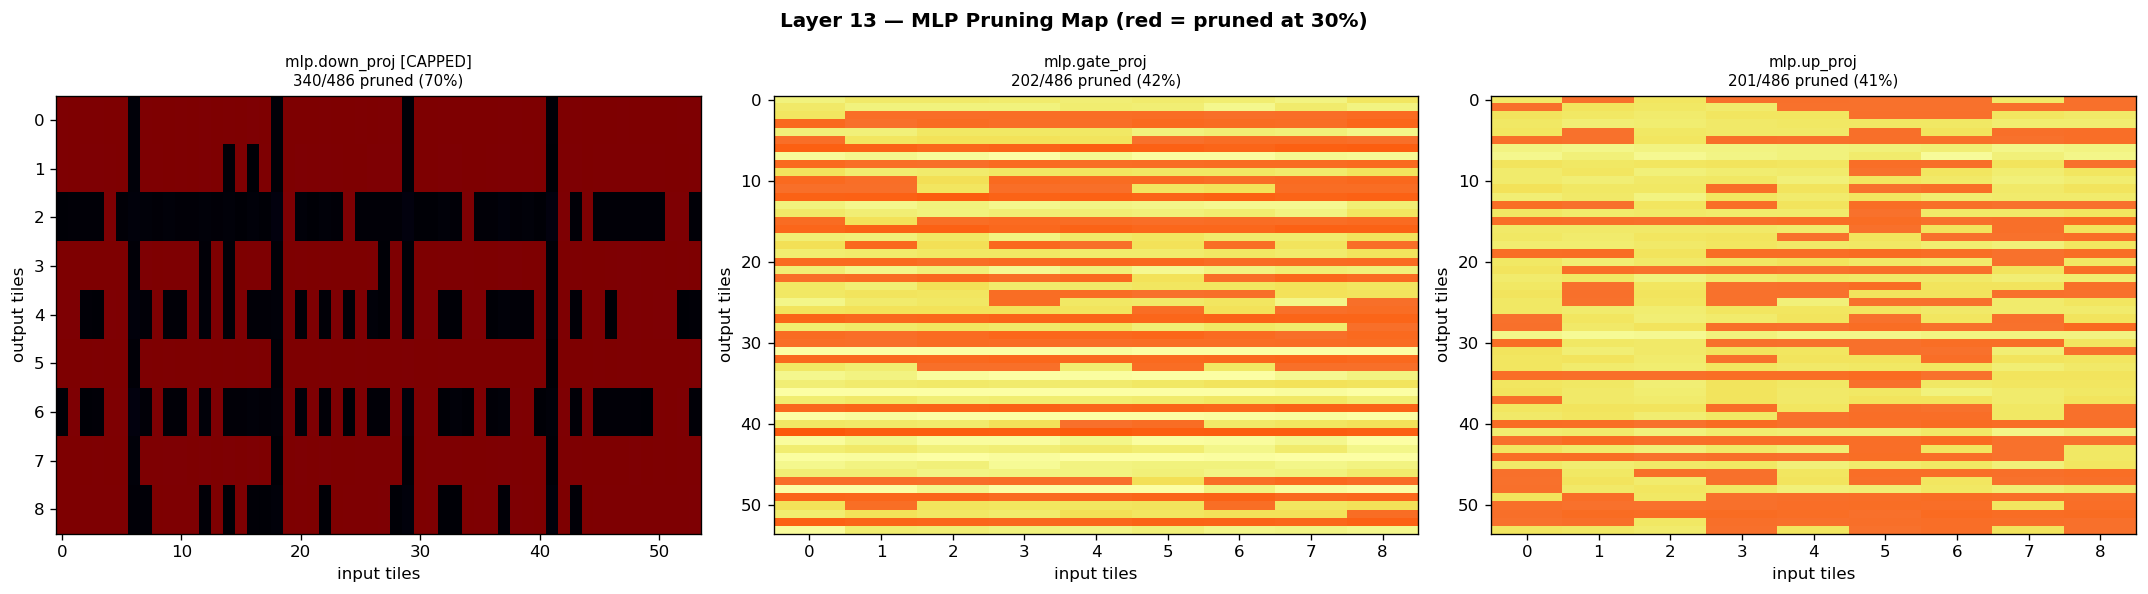

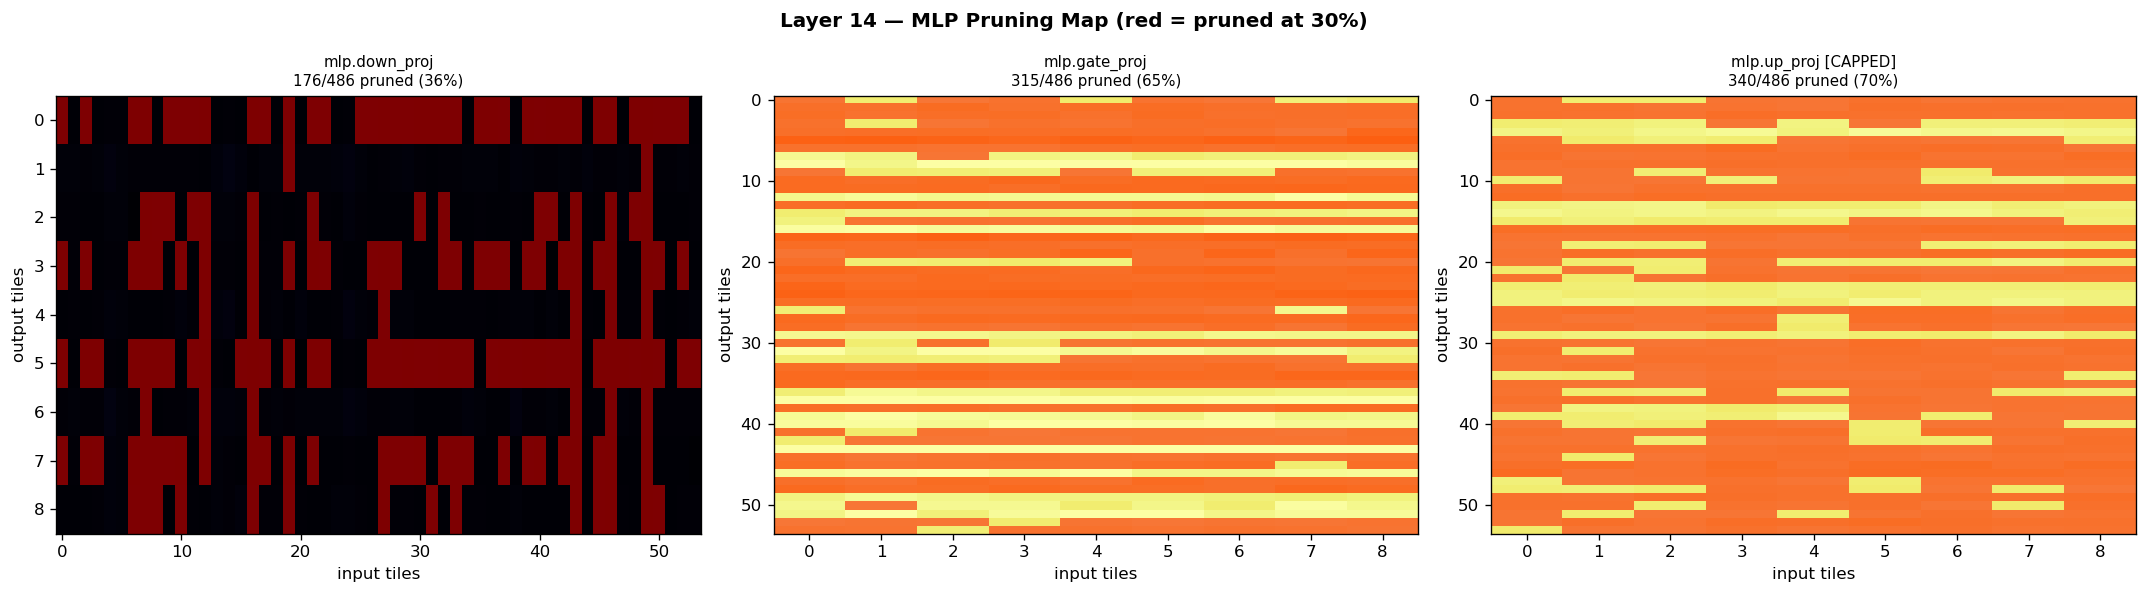

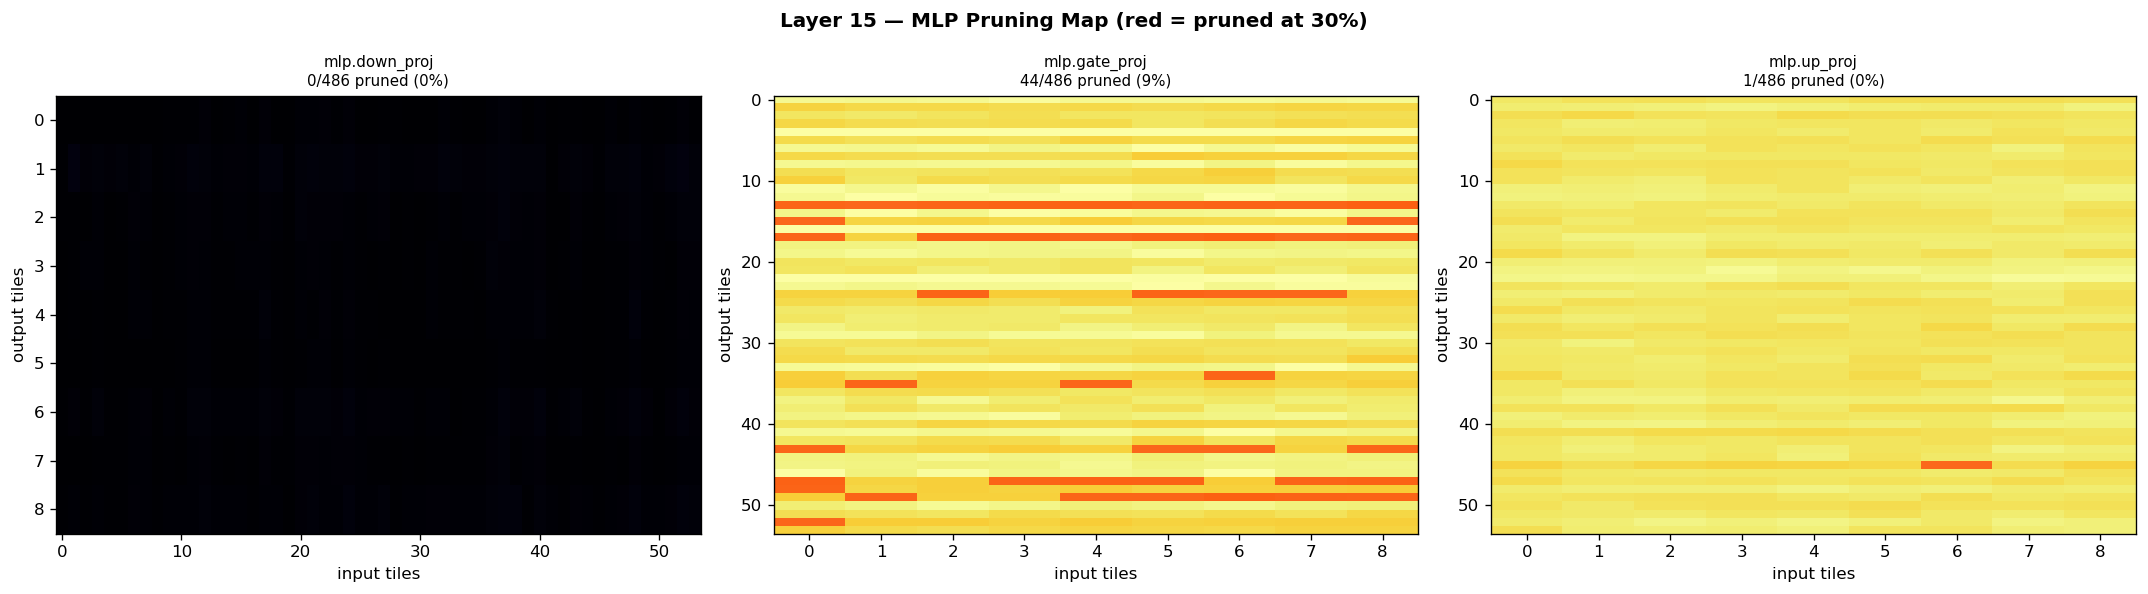

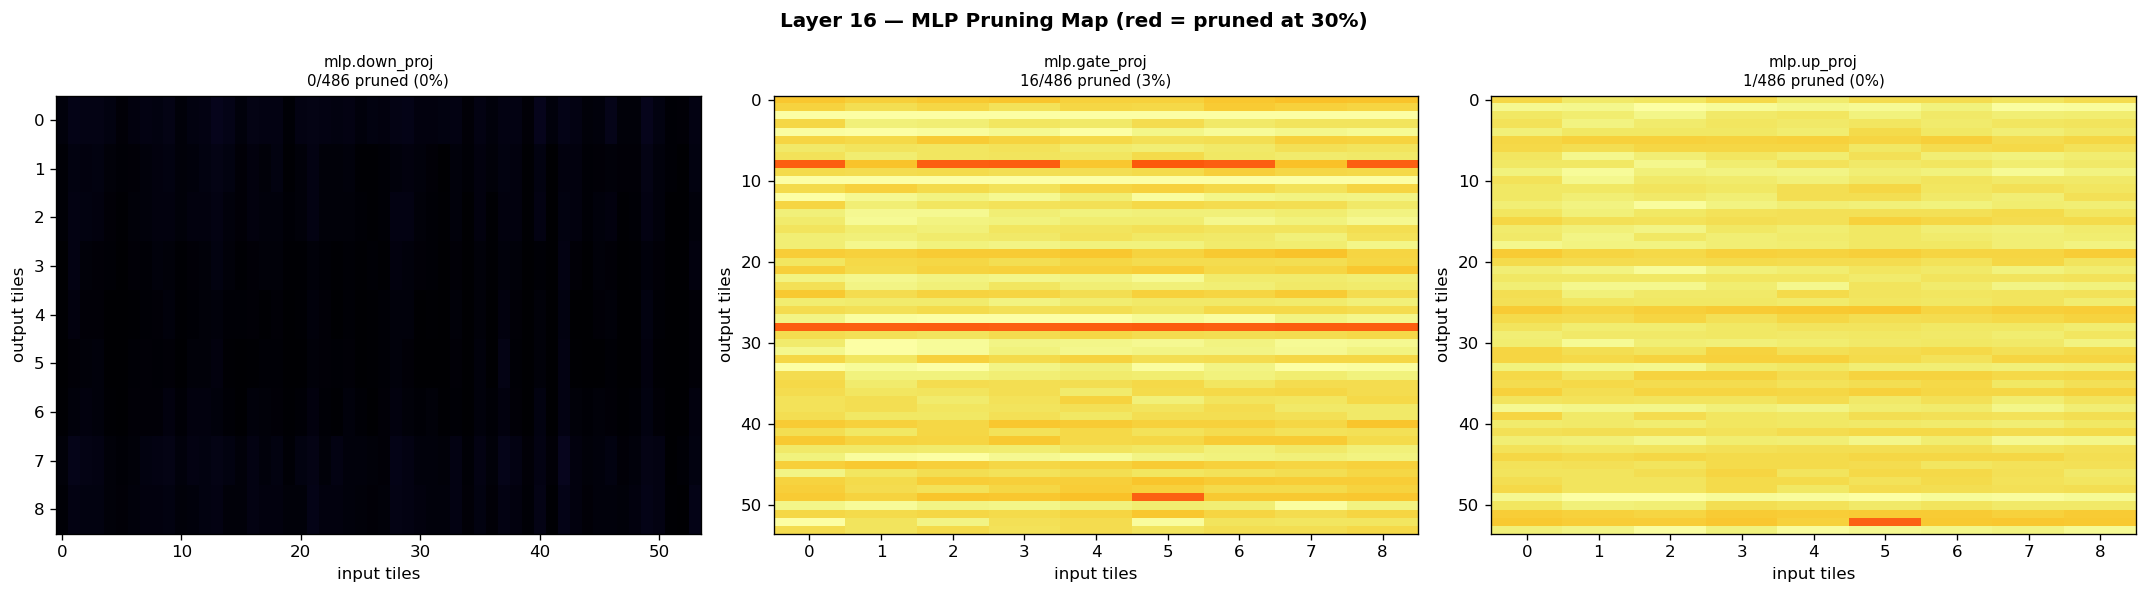

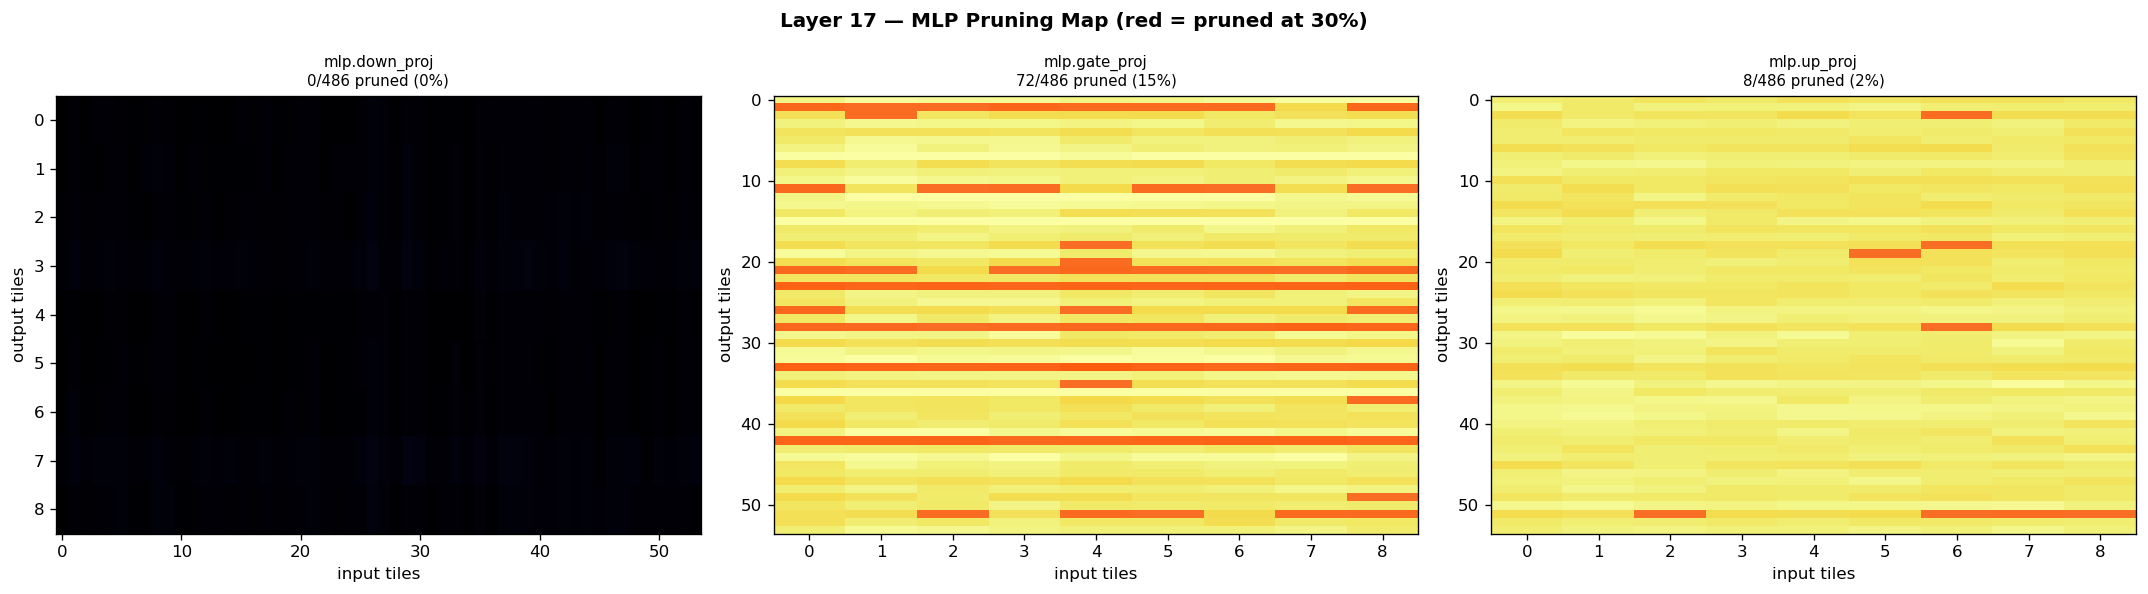

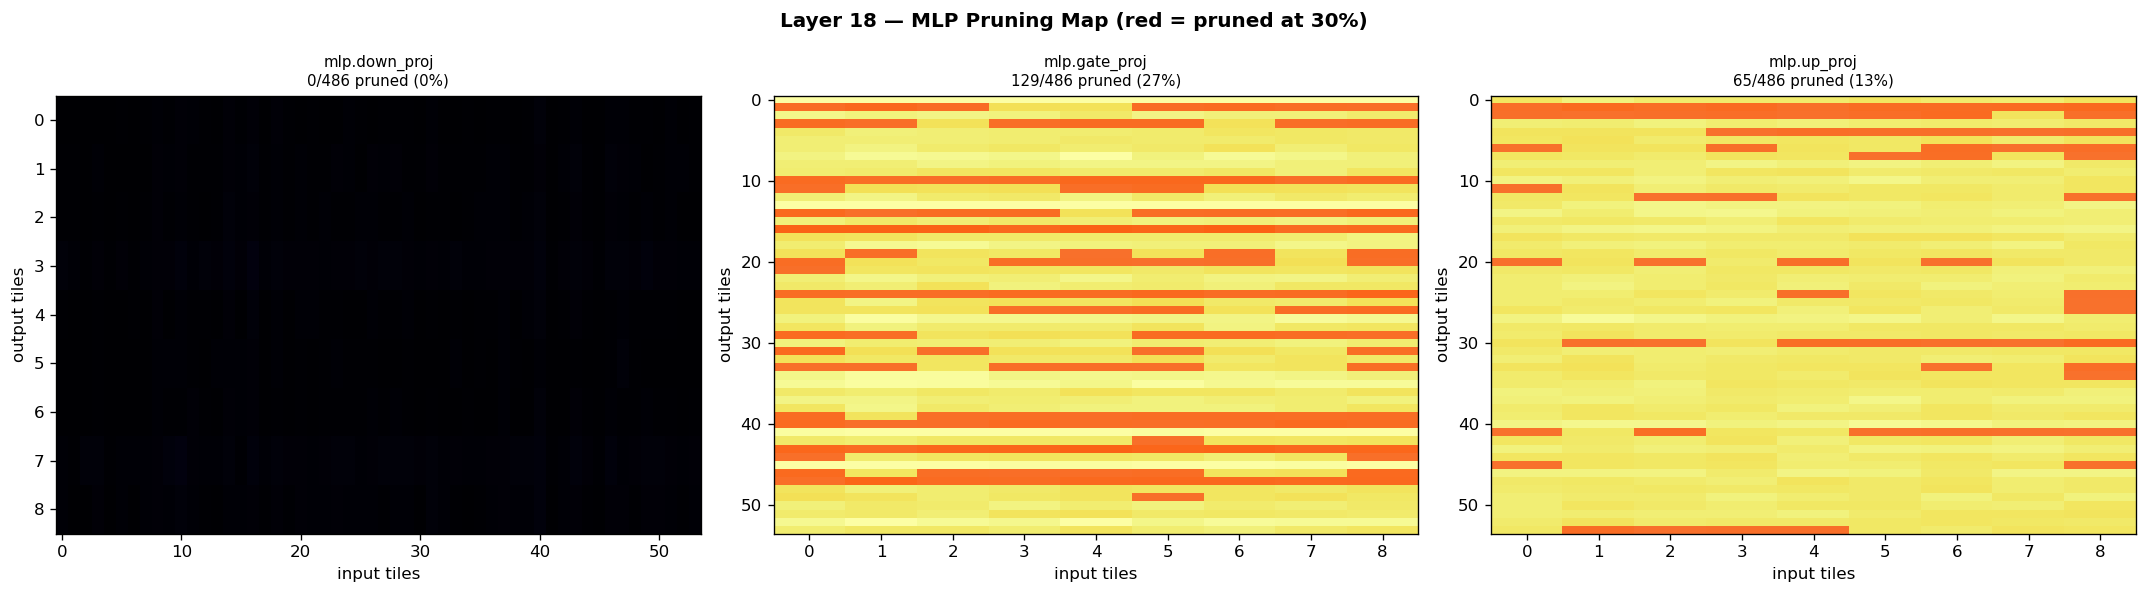

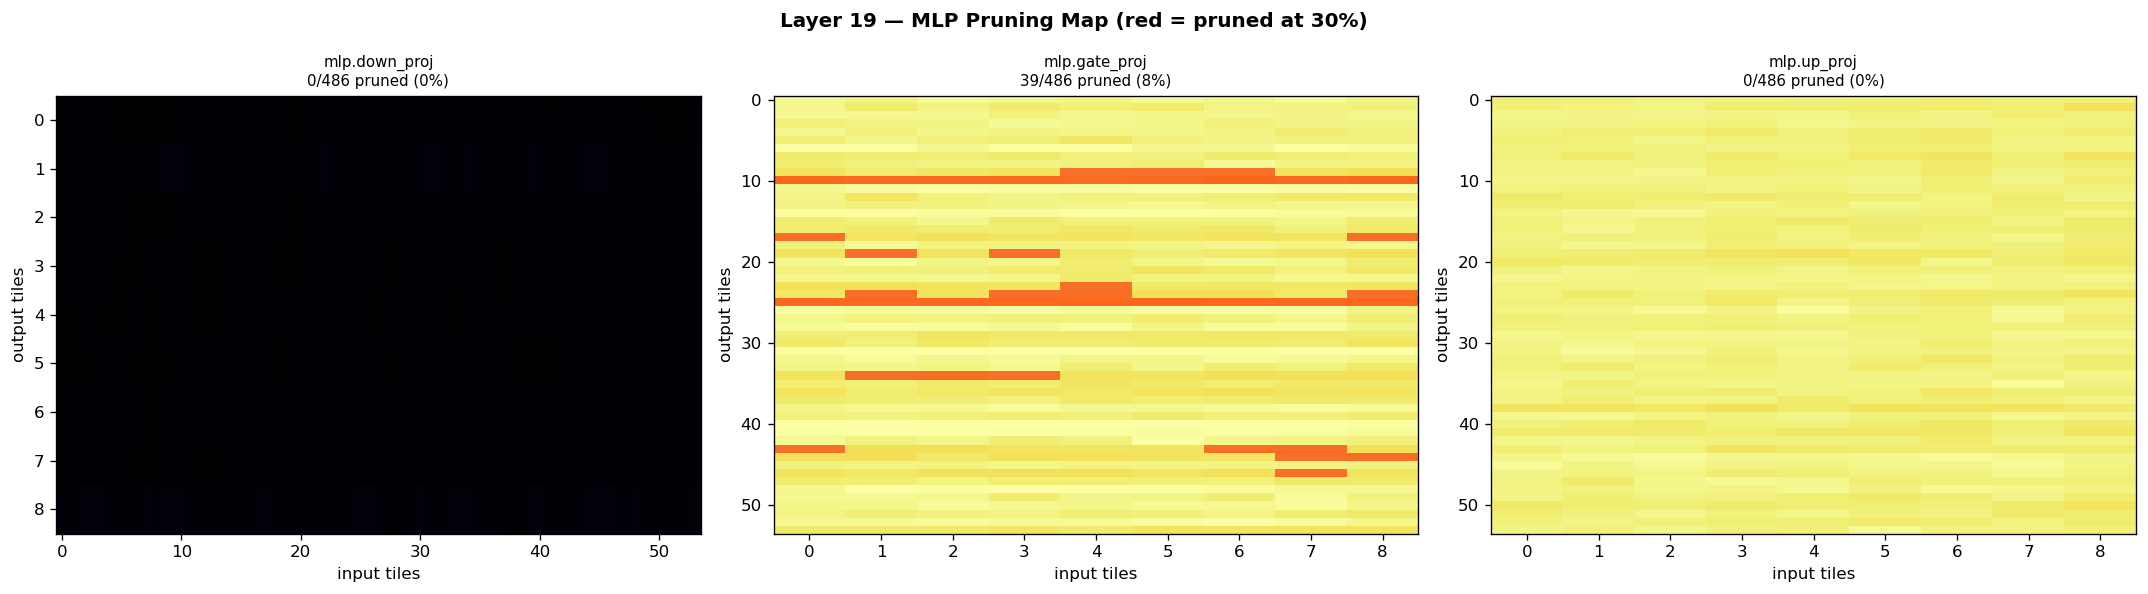

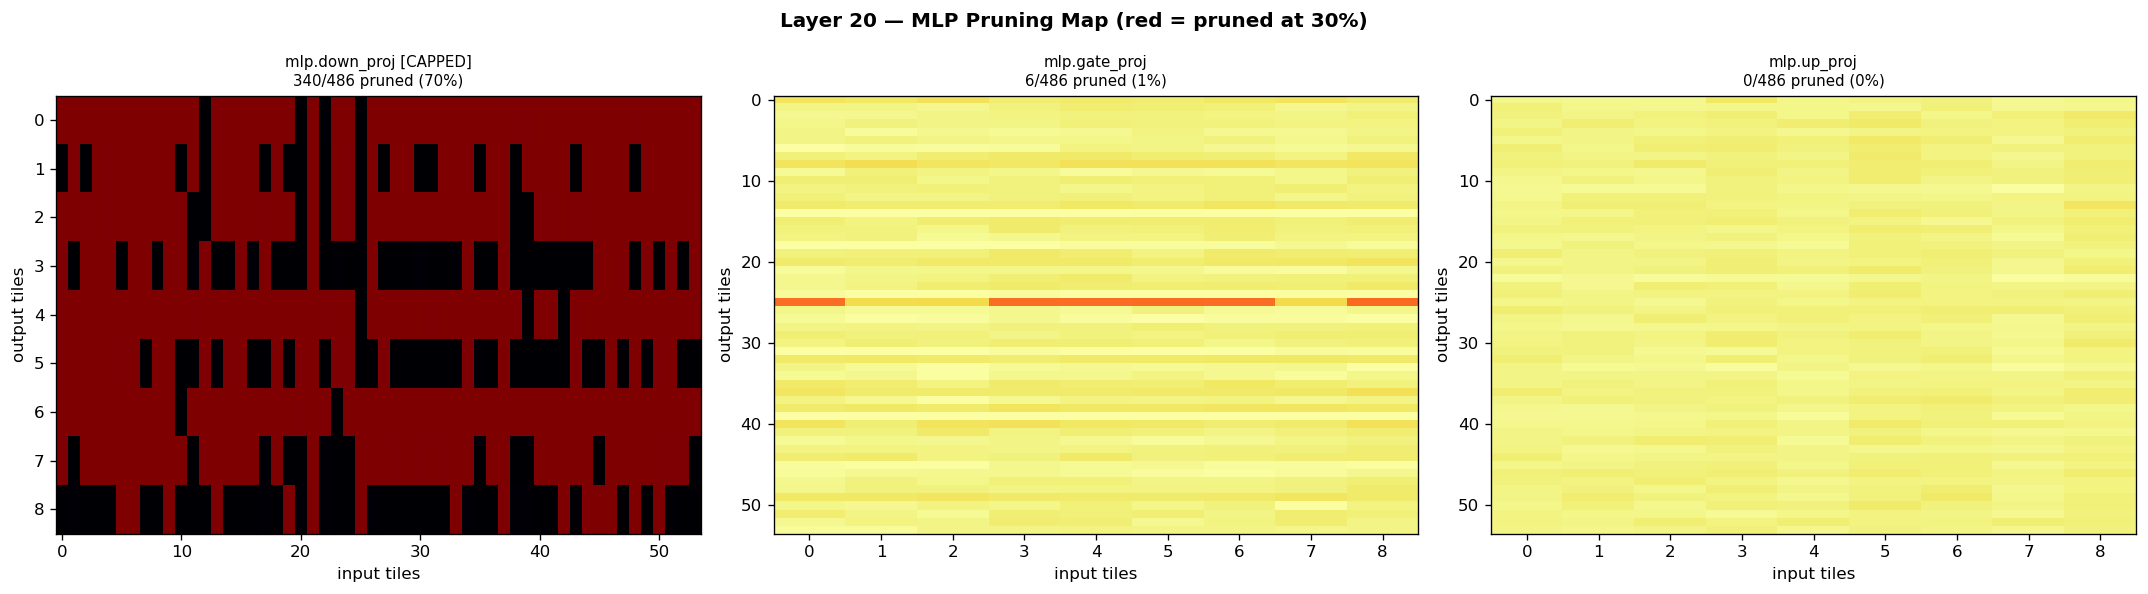

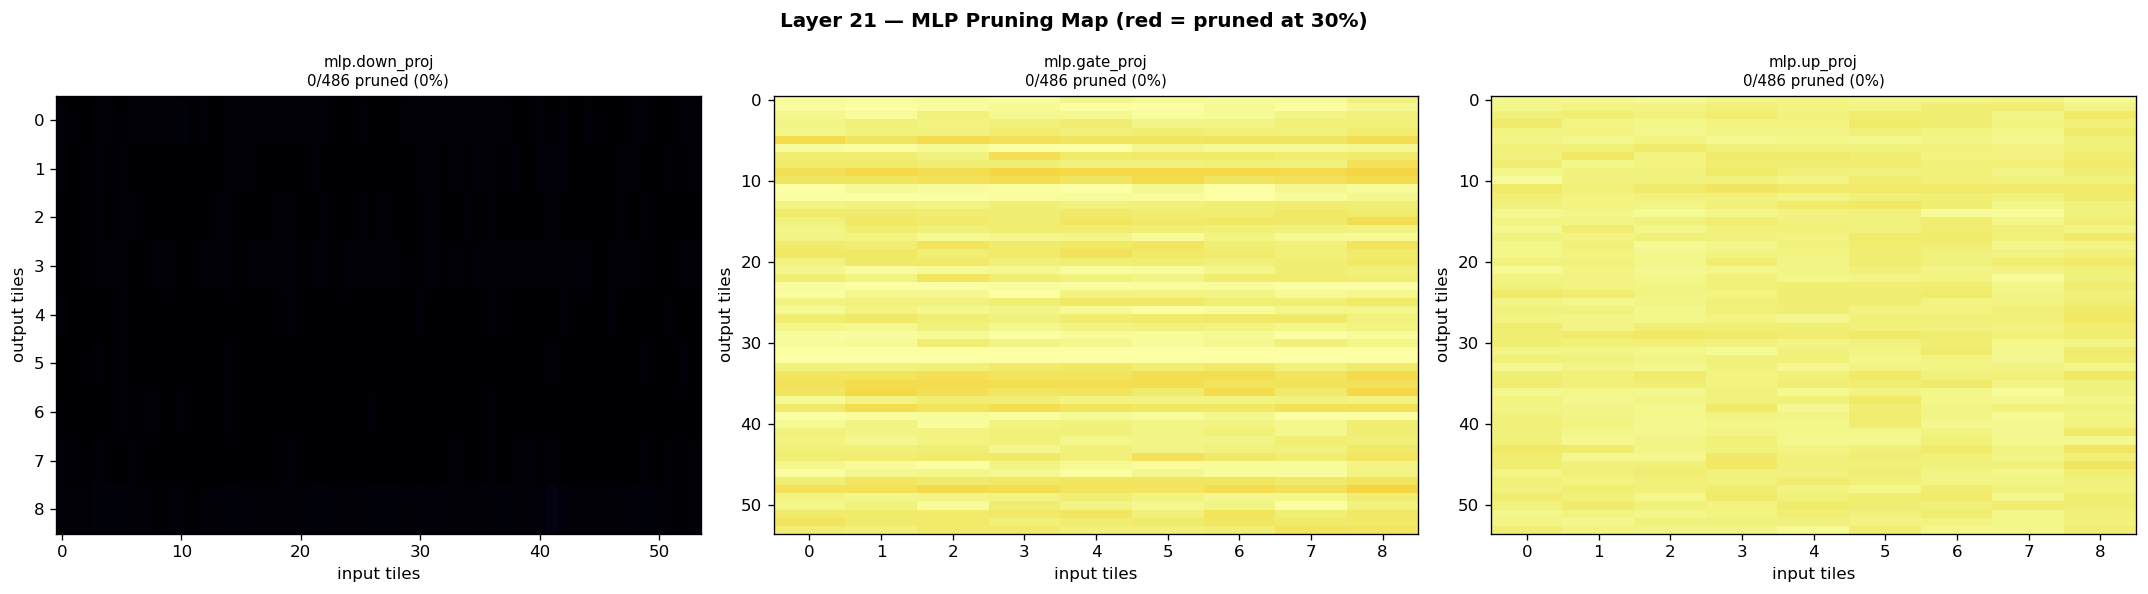

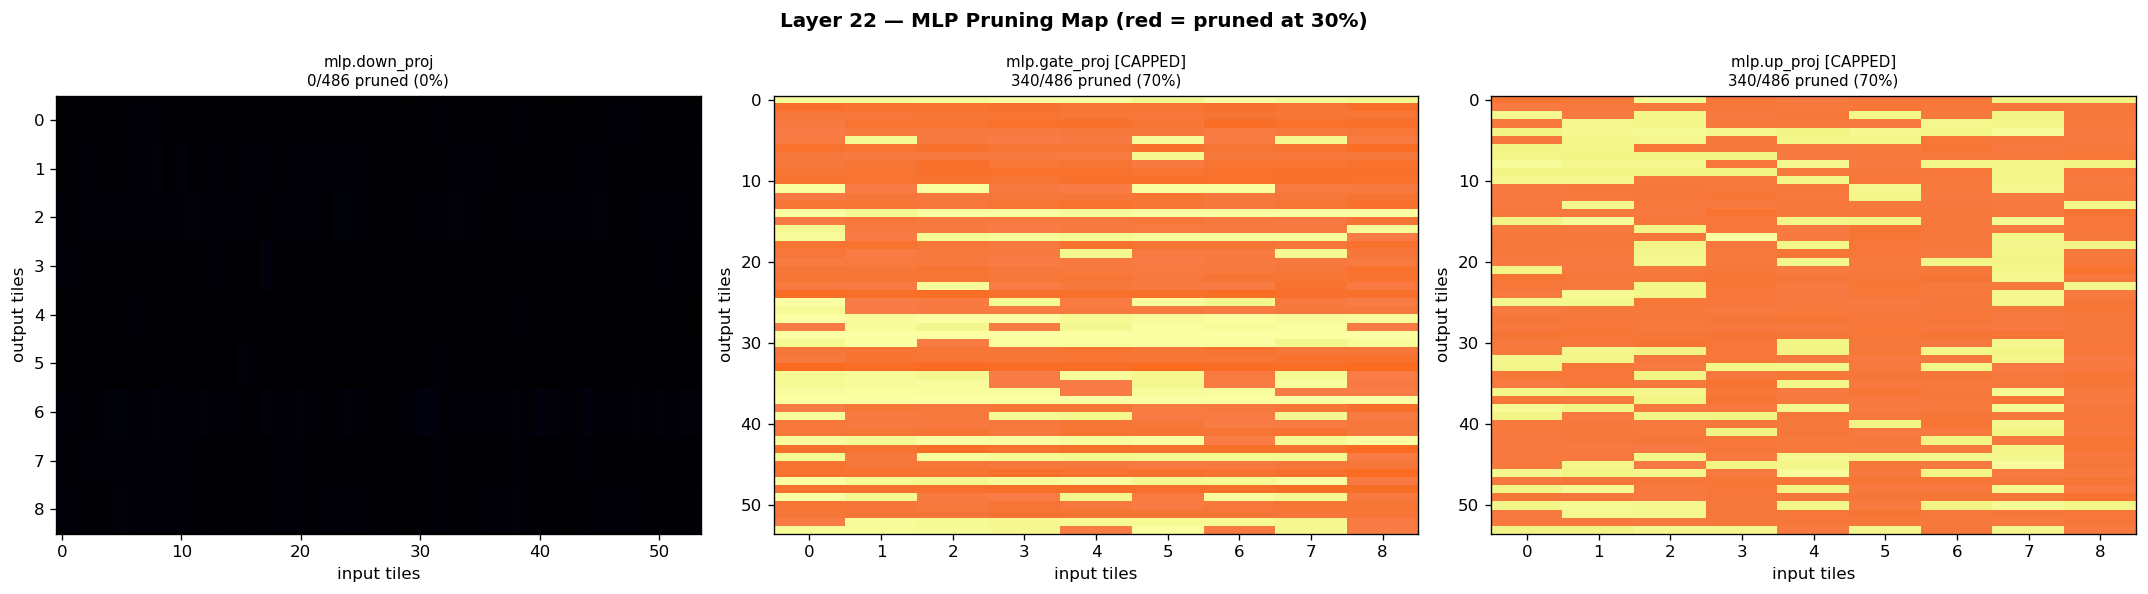

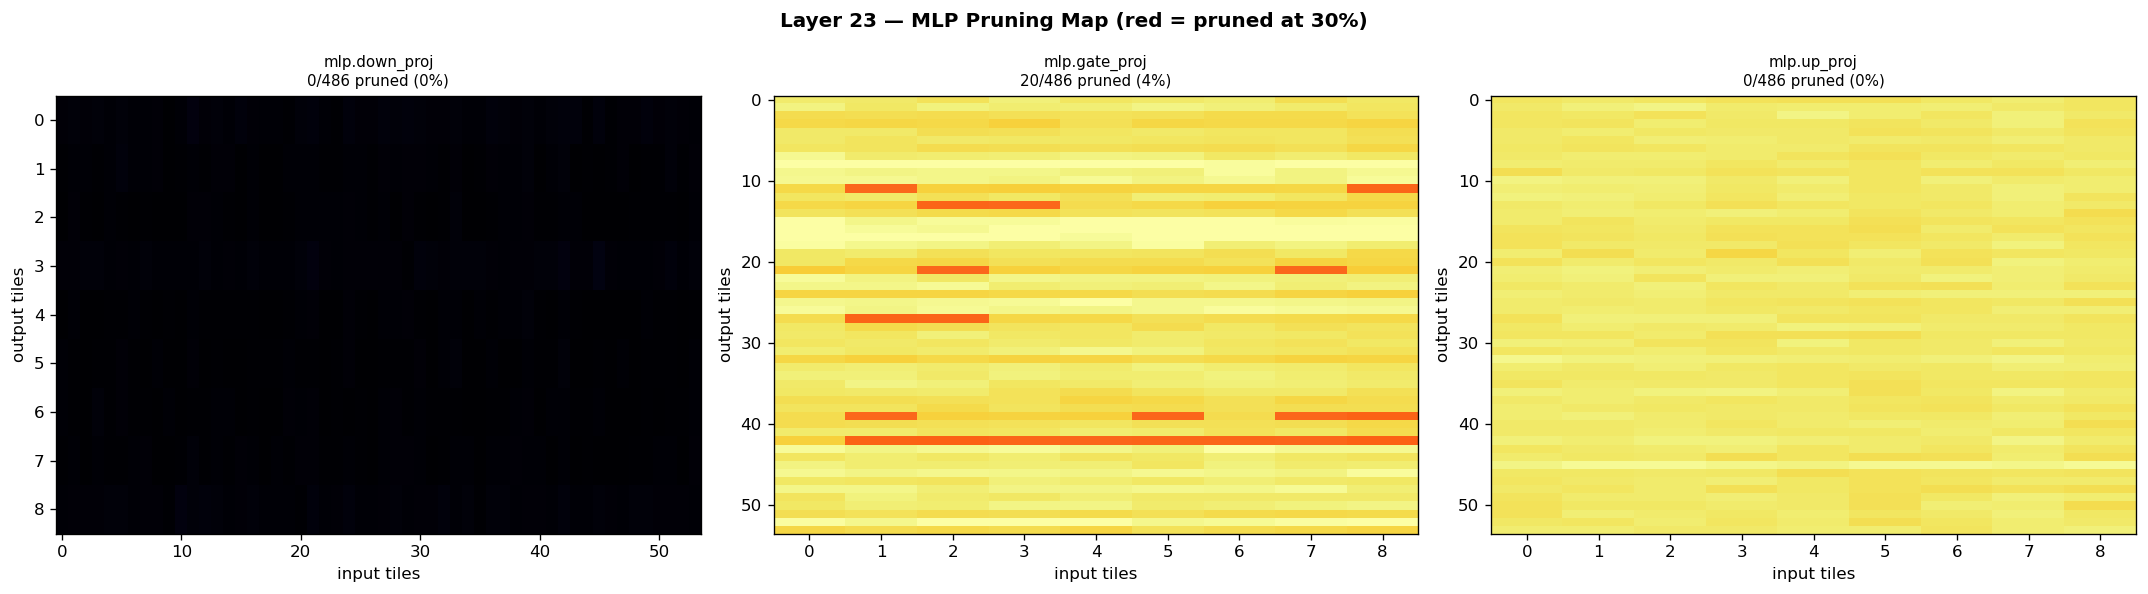

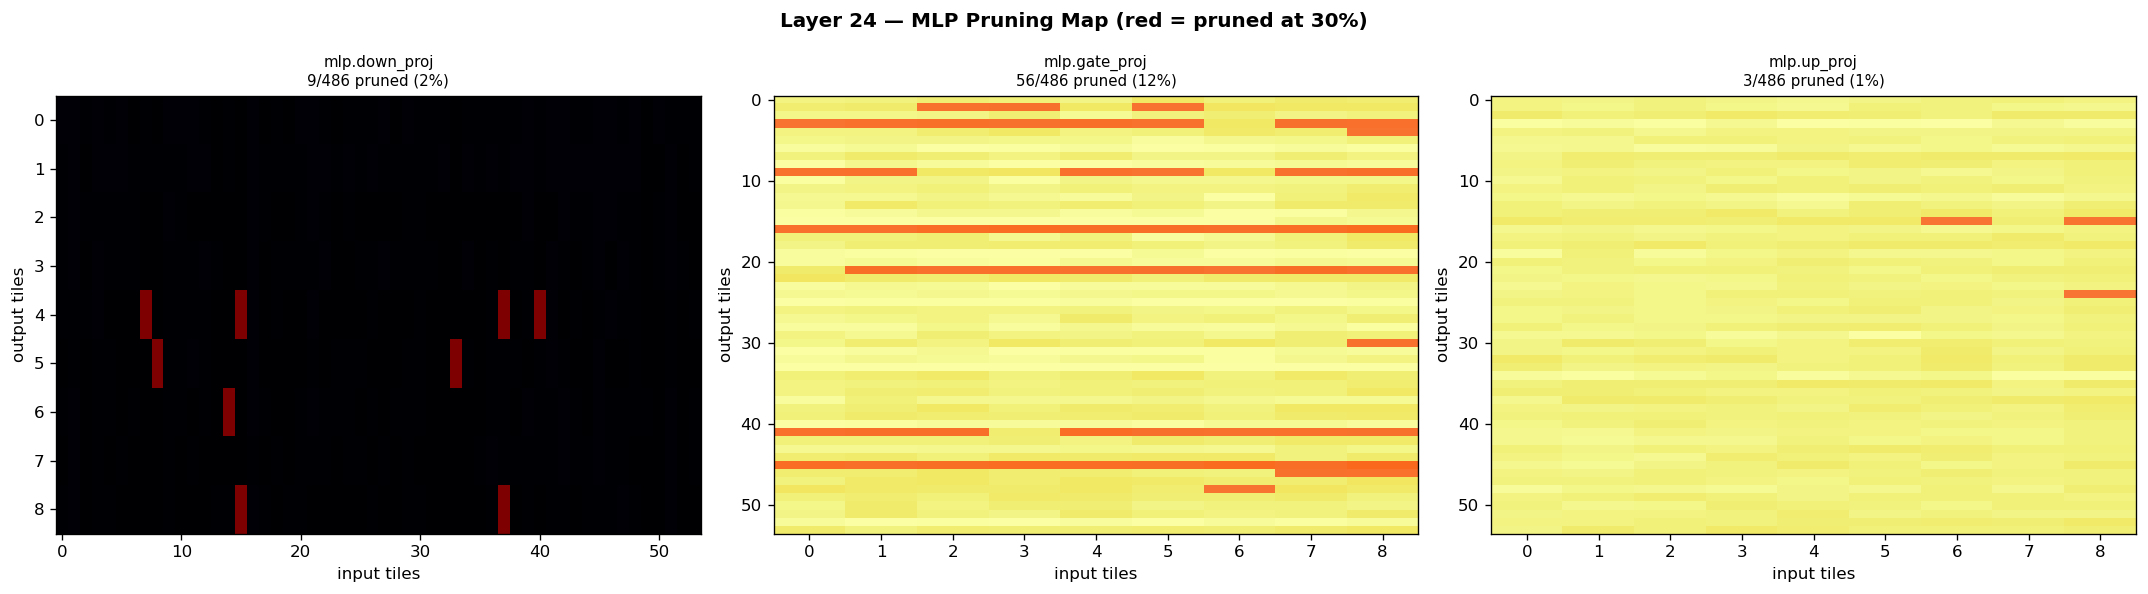

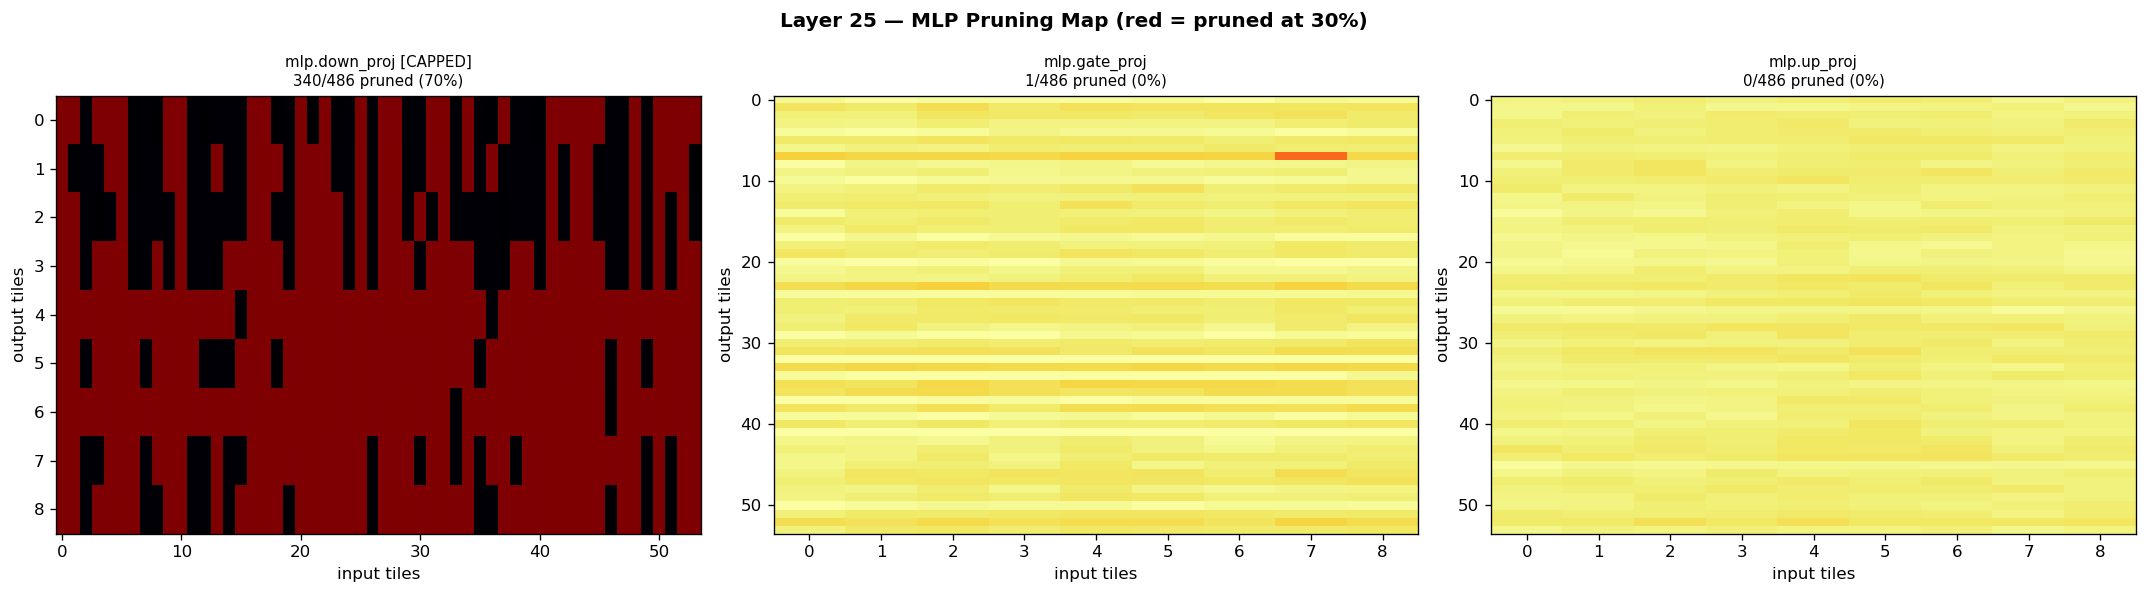

In [9]:
def get_mlp_components(layer_idx: int) -> dict:
    """Return only MLP components for a layer (raw scores)."""
    return {k: v for k, v in layer_components[layer_idx].items()
            if any(p in k for p in config.PRUNE_TARGETS_PATTERNS)}

def get_mlp_components_norm(layer_idx: int) -> dict:
    """Return only MLP components for a layer (normalized scores)."""
    return layer_components_norm.get(layer_idx, {})

def get_capped_mask_viz(norm_map: np.ndarray, threshold: float,
                        max_prune: float = config.MAX_PRUNE_PER_MATRIX) -> np.ndarray:
    """Same cap logic used in apply_tile_pruning, for consistent visualization."""
    global_mask = norm_map < threshold
    if global_mask.mean() <= max_prune:
        return global_mask
    local_threshold = float(np.percentile(norm_map.ravel(), max_prune * 100))
    return norm_map < local_threshold

def plot_pruning_map(layer_idx: int, raw_components: dict, norm_components: dict, threshold: float):
    """Show which tiles would be pruned (with per-matrix cap). Heatmap uses raw, mask uses normalized."""
    n = len(raw_components)
    if n == 0:
        return
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 5))
    if n == 1:
        axes = [axes]
    
    all_vals = np.concatenate([m.ravel() for m in raw_components.values()])
    vmin, vmax = np.percentile(all_vals, [2, 98])
    
    for ax, (comp_name, raw_map) in zip(axes, sorted(raw_components.items())):
        ax.imshow(raw_map, aspect="auto", cmap="inferno", vmin=vmin, vmax=vmax, interpolation="nearest")
        
        norm_map = norm_components.get(comp_name)
        if norm_map is not None:
            prune_mask = get_capped_mask_viz(norm_map, threshold)
        else:
            prune_mask = np.zeros_like(raw_map, dtype=bool)
        
        overlay = np.zeros((*raw_map.shape, 4))
        overlay[prune_mask] = [1, 0, 0, 0.5]
        ax.imshow(overlay, aspect="auto", interpolation="nearest")
        
        n_pruned = prune_mask.sum()
        n_total = prune_mask.size
        was_capped = (norm_map < threshold).mean() > config.MAX_PRUNE_PER_MATRIX if norm_map is not None else False
        cap_label = " [CAPPED]" if was_capped else ""
        ax.set_title(f"{comp_name}{cap_label}\n{n_pruned}/{n_total} pruned ({n_pruned/n_total*100:.0f}%)", fontsize=9)
        ax.set_xlabel("input tiles")
        ax.set_ylabel("output tiles")
    
    fig.suptitle(f"Layer {layer_idx} — MLP Pruning Map (red = pruned at {PRUNE_RATIO*100:.0f}%)", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()

# Show ALL layers
for li in range(n_layers):
    raw = get_mlp_components(li)
    norm = get_mlp_components_norm(li)
    if raw:
        plot_pruning_map(li, raw, norm, threshold)

## 7. Per-layer MLP pruning density

How much does each layer's MLP get pruned under the global threshold? Layers that lose more MLP tiles are the "expendable" ones. Layers that keep most tiles are the critical reasoning circuits — candidates for duplication.

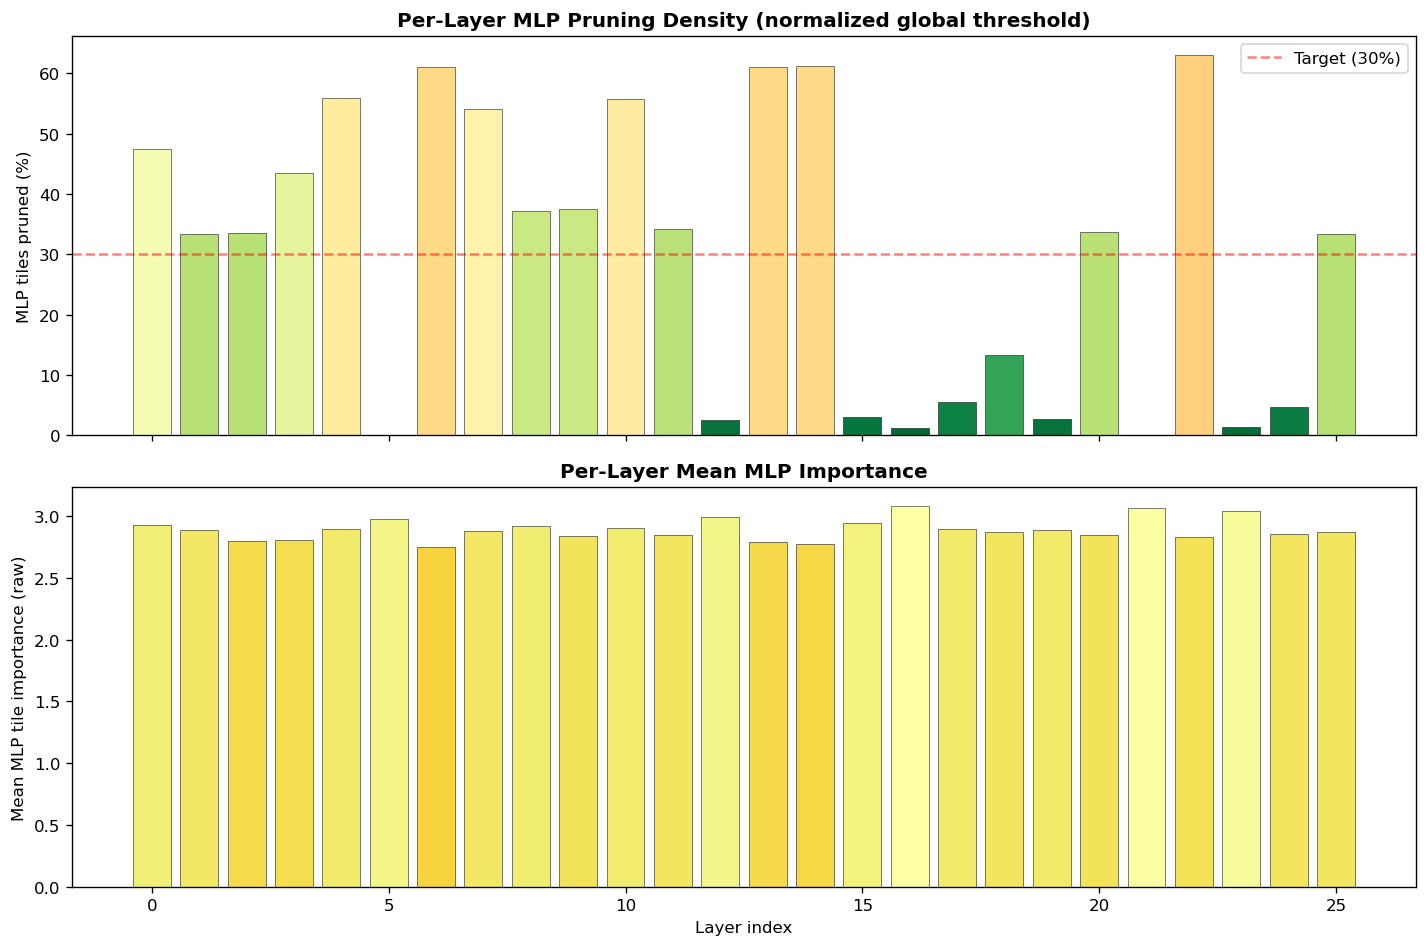

Most pruned layer:  22 (63.0% MLP tiles removed)
Least pruned layer: 5 (0.0% MLP tiles removed)

Duplication candidates (least pruned = most important): layers [np.int64(5), np.int64(12), np.int64(16), np.int64(21), np.int64(23)]


In [10]:
# Per-layer MLP pruning stats (using normalized scores for pruning decisions)
layer_prune_ratios = []
layer_mean_importance = []

for li in range(n_layers):
    norm_comps = get_mlp_components_norm(li)
    raw_comps = get_mlp_components(li)
    if not norm_comps:
        layer_prune_ratios.append(0.0)
        layer_mean_importance.append(0.0)
        continue
    norm_tiles = np.concatenate([m.ravel() for m in norm_comps.values()])
    raw_tiles = np.concatenate([m.ravel() for m in raw_comps.values()])
    pruned = (norm_tiles < threshold).sum()
    layer_prune_ratios.append(pruned / len(norm_tiles))
    layer_mean_importance.append(raw_tiles.mean())

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

colors = plt.cm.RdYlGn_r(np.array(layer_prune_ratios))
ax1.bar(range(n_layers), [r * 100 for r in layer_prune_ratios], color=colors, edgecolor="black", linewidth=0.3)
ax1.axhline(PRUNE_RATIO * 100, color="red", linestyle="--", alpha=0.5, label=f"Target ({PRUNE_RATIO*100:.0f}%)")
ax1.set_ylabel("MLP tiles pruned (%)")
ax1.set_title("Per-Layer MLP Pruning Density (normalized global threshold)", fontweight="bold")
ax1.legend()

max_imp = max(layer_mean_importance) if max(layer_mean_importance) > 0 else 1
colors2 = plt.cm.inferno(np.array(layer_mean_importance) / max_imp)
ax2.bar(range(n_layers), layer_mean_importance, color=colors2, edgecolor="black", linewidth=0.3)
ax2.set_xlabel("Layer index")
ax2.set_ylabel("Mean MLP tile importance (raw)")
ax2.set_title("Per-Layer Mean MLP Importance", fontweight="bold")

plt.tight_layout()
plt.show()

most_pruned = np.argmax(layer_prune_ratios)
least_pruned = np.argmin(layer_prune_ratios)
print(f"Most pruned layer:  {most_pruned} ({layer_prune_ratios[most_pruned]*100:.1f}% MLP tiles removed)")
print(f"Least pruned layer: {least_pruned} ({layer_prune_ratios[least_pruned]*100:.1f}% MLP tiles removed)")
print(f"\nDuplication candidates (least pruned = most important):"
      f" layers {sorted(np.argsort(layer_prune_ratios)[:5])}")

## 8. MLP importance distribution — where do the tiles fall?

Histogram of MLP tile importance scores (the pruning pool). The vertical line shows the pruning threshold. A bimodal split = genuinely dead regions exist.

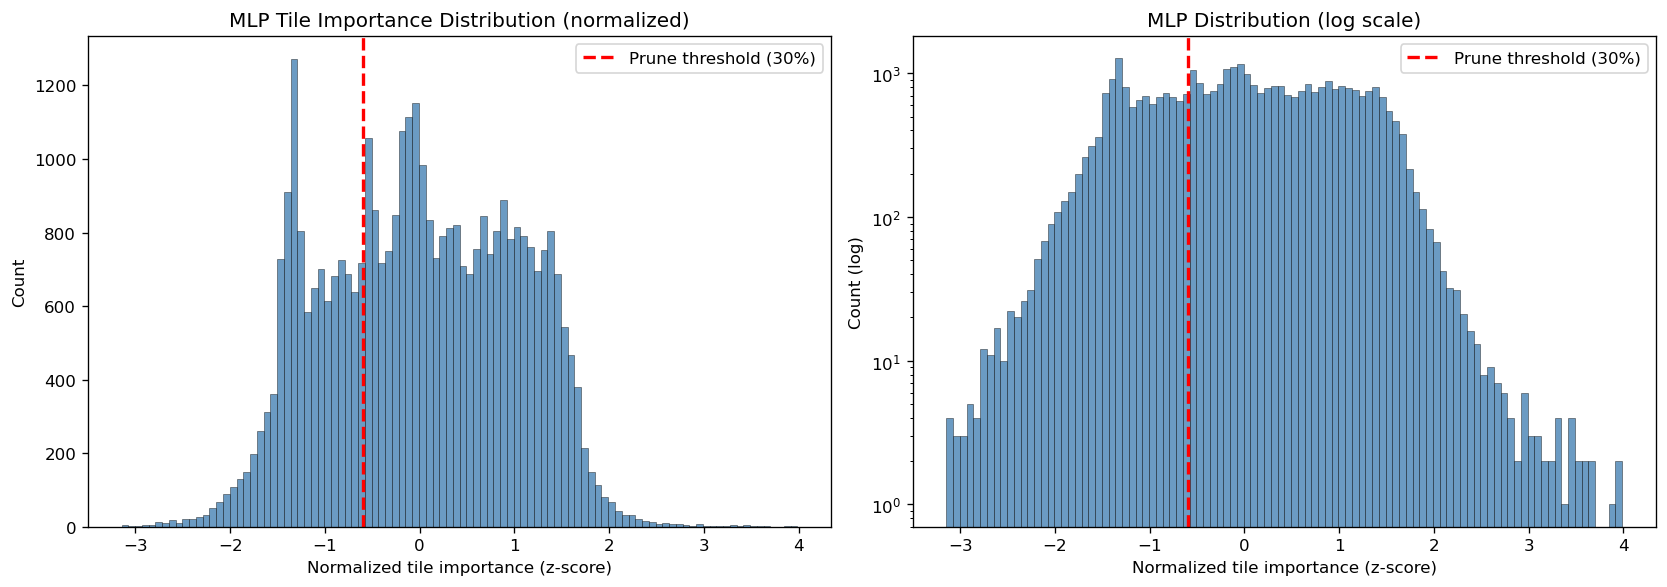

MLP tiles: 37908
Min: -3.1455, Max: 3.9881
Mean: 0.0000, Std: 1.0000
Median: -0.0191


In [11]:
all_mlp_norm_scores = np.concatenate([m.ravel() for m in importance_maps_mlp_norm.values()])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(all_mlp_norm_scores, bins=100, color="steelblue", edgecolor="black", linewidth=0.3, alpha=0.8)
ax1.axvline(threshold, color="red", linestyle="--", linewidth=2, label=f"Prune threshold ({PRUNE_RATIO*100:.0f}%)")
ax1.set_xlabel("Normalized tile importance (z-score)")
ax1.set_ylabel("Count")
ax1.set_title("MLP Tile Importance Distribution (normalized)")
ax1.legend()

ax2.hist(all_mlp_norm_scores, bins=100, color="steelblue", edgecolor="black", linewidth=0.3, alpha=0.8)
ax2.axvline(threshold, color="red", linestyle="--", linewidth=2, label=f"Prune threshold ({PRUNE_RATIO*100:.0f}%)")
ax2.set_yscale("log")
ax2.set_xlabel("Normalized tile importance (z-score)")
ax2.set_ylabel("Count (log)")
ax2.set_title("MLP Distribution (log scale)")
ax2.legend()

plt.tight_layout()
plt.show()

print(f"MLP tiles: {len(all_mlp_norm_scores)}")
print(f"Min: {all_mlp_norm_scores.min():.4f}, Max: {all_mlp_norm_scores.max():.4f}")
print(f"Mean: {all_mlp_norm_scores.mean():.4f}, Std: {all_mlp_norm_scores.std():.4f}")
print(f"Median: {np.median(all_mlp_norm_scores):.4f}")

## 9. Attention vs MLP comparison (visualization only)

How do importance distributions compare? Attention is shown for context but is **not** in the pruning pool.

> **Future experiment:** Try tile-pruning attention projections and measure impact on head coherence.

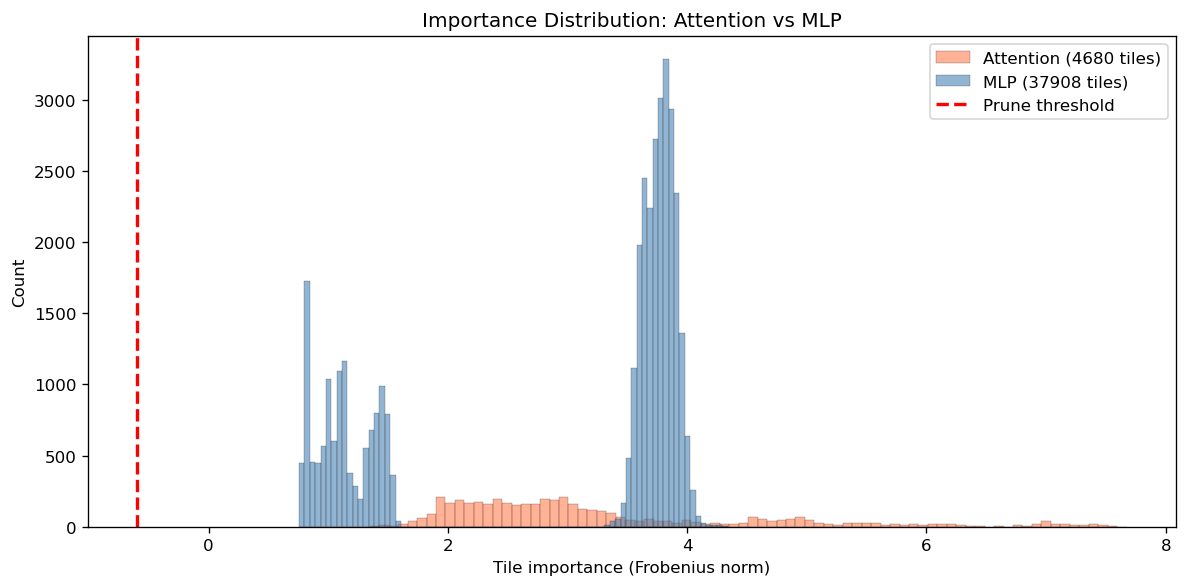

Attention — mean: 3.2399, would-be-pruned: 0.0%
MLP      — mean: 2.8924, pruned:          0.0%

Note: Attention tiles are NOT pruned — shown for comparison only.


In [12]:
# Group scores by component type
attn_keywords = ["q_proj", "k_proj", "v_proj", "o_proj", "qkv_proj", "self_attn"]
mlp_keywords = ["gate_proj", "up_proj", "down_proj", "mlp"]

attn_scores = []
mlp_scores = []

for name, imp_map in importance_maps_all.items():
    name_lower = name.lower()
    if any(k in name_lower for k in attn_keywords):
        attn_scores.extend(imp_map.ravel().tolist())
    elif any(k in name_lower for k in mlp_keywords):
        mlp_scores.extend(imp_map.ravel().tolist())

fig, ax = plt.subplots(figsize=(10, 5))
if attn_scores:
    ax.hist(attn_scores, bins=80, alpha=0.6, label=f"Attention ({len(attn_scores)} tiles)", color="coral", edgecolor="black", linewidth=0.2)
if mlp_scores:
    ax.hist(mlp_scores, bins=80, alpha=0.6, label=f"MLP ({len(mlp_scores)} tiles)", color="steelblue", edgecolor="black", linewidth=0.2)
ax.axvline(threshold, color="red", linestyle="--", linewidth=2, label=f"Prune threshold")
ax.set_xlabel("Tile importance (Frobenius norm)")
ax.set_ylabel("Count")
ax.set_title("Importance Distribution: Attention vs MLP")
ax.legend()
plt.tight_layout()
plt.show()

if attn_scores and mlp_scores:
    attn_arr = np.array(attn_scores)
    mlp_arr = np.array(mlp_scores)
    print(f"Attention — mean: {attn_arr.mean():.4f}, would-be-pruned: {(attn_arr < threshold).mean()*100:.1f}%")
    print(f"MLP      — mean: {mlp_arr.mean():.4f}, pruned:          {(mlp_arr < threshold).mean()*100:.1f}%")
    print(f"\nNote: Attention tiles are NOT pruned — shown for comparison only.")

## 10. Zoomed spatial view — single weight matrix deep dive

Pick any layer/component and see the full tile grid at high resolution. Useful for spotting spatial patterns — do dead tiles cluster in rows (output neurons), columns (input features), or patches?

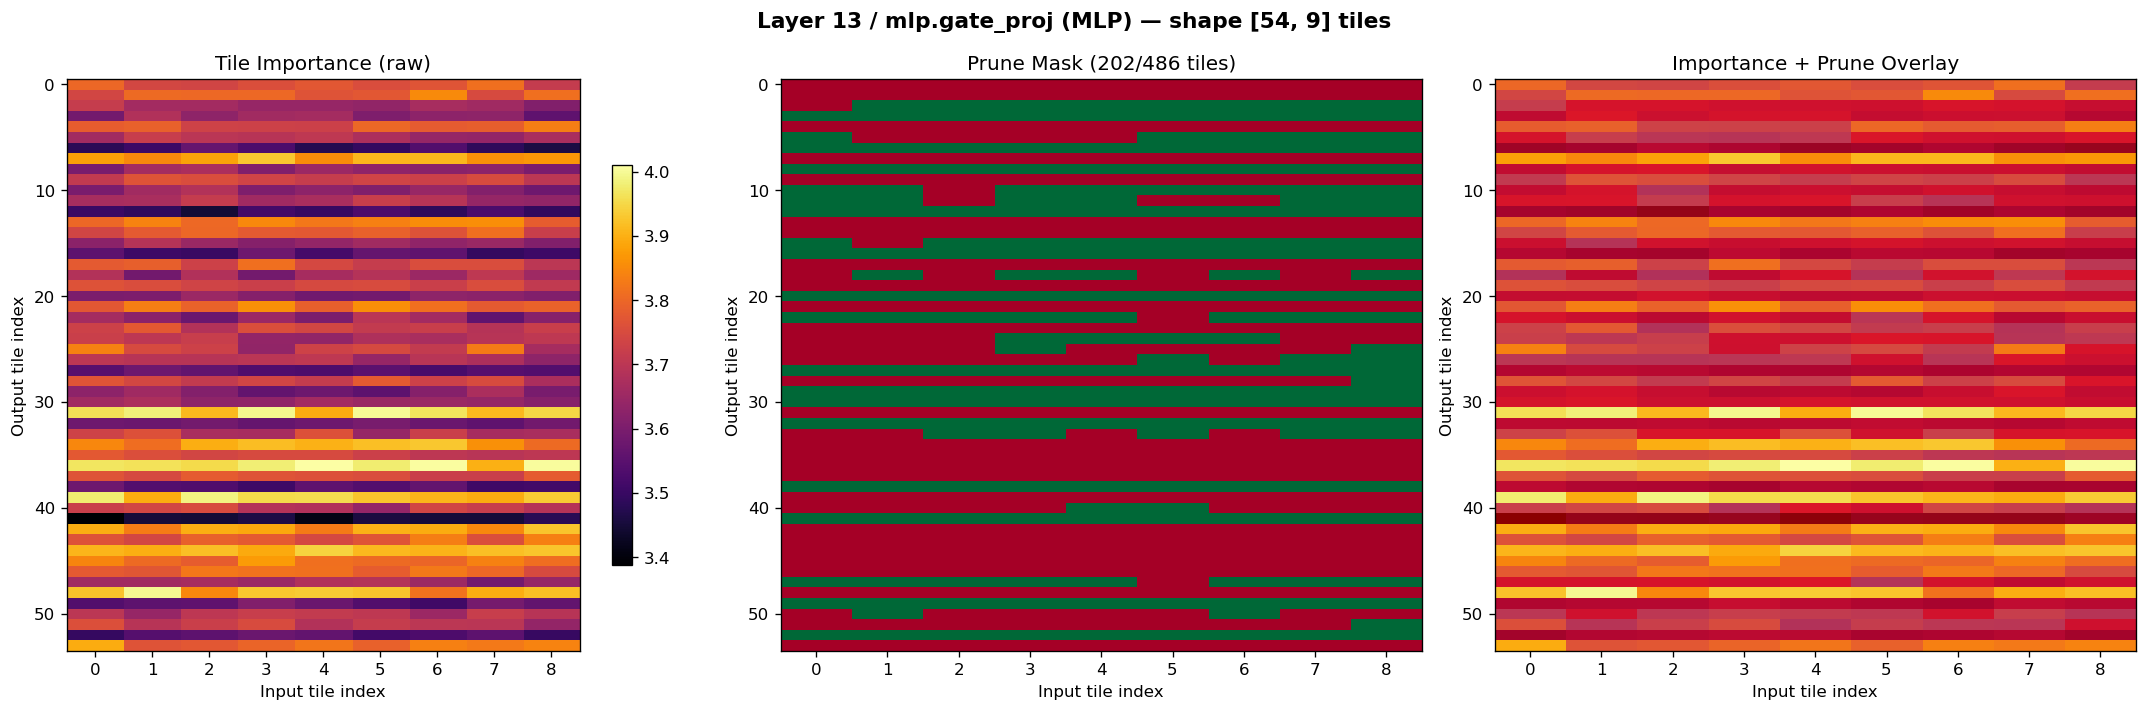

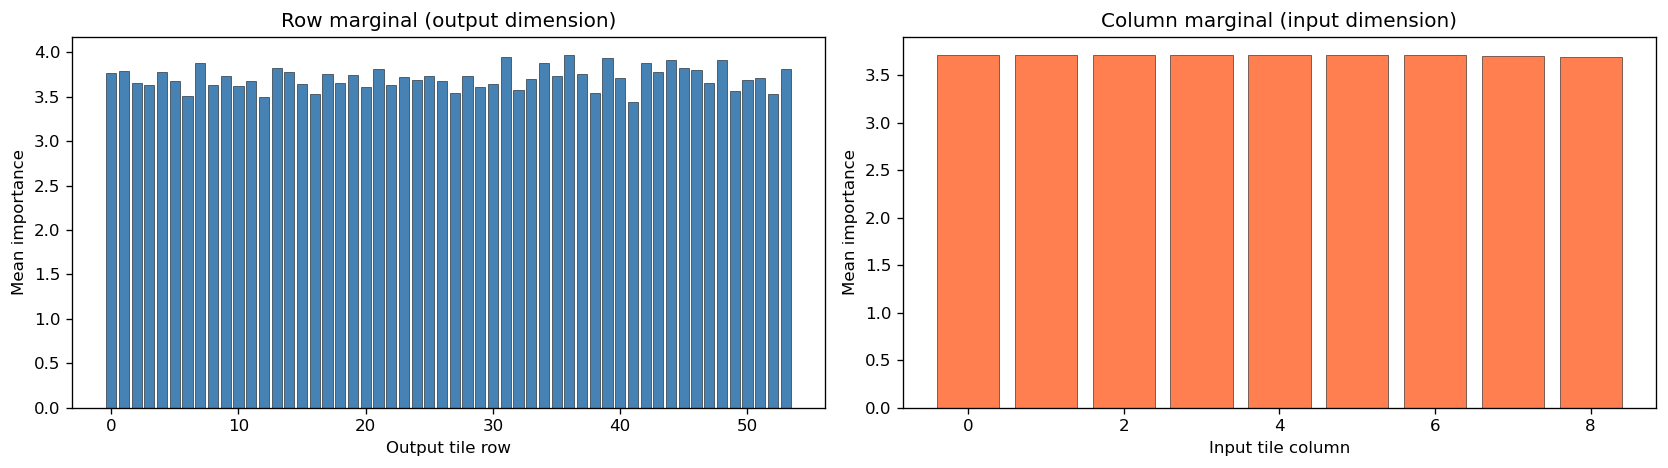

In [13]:
# ---- CONFIGURE: pick a layer and MLP component to zoom into ----
ZOOM_LAYER = n_layers // 2
mlp_comps = get_mlp_components(ZOOM_LAYER)
mlp_comps_n = get_mlp_components_norm(ZOOM_LAYER)
ZOOM_COMP = list(mlp_comps.keys())[0]
# ----------------------------------------------------------------

imp_map = mlp_comps[ZOOM_COMP]
norm_map = mlp_comps_n[ZOOM_COMP]
prune_mask = norm_map < threshold

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

im = axes[0].imshow(imp_map, aspect="auto", cmap="inferno", interpolation="nearest")
axes[0].set_title("Tile Importance (raw)")
fig.colorbar(im, ax=axes[0], shrink=0.7)

axes[1].imshow(prune_mask.astype(float), aspect="auto", cmap="RdYlGn", interpolation="nearest", vmin=0, vmax=1)
axes[1].set_title(f"Prune Mask ({prune_mask.sum()}/{prune_mask.size} tiles)")

axes[2].imshow(imp_map, aspect="auto", cmap="inferno", interpolation="nearest")
overlay = np.zeros((*imp_map.shape, 4))
overlay[prune_mask] = [1, 0, 0, 0.55]
axes[2].imshow(overlay, aspect="auto", interpolation="nearest")
axes[2].set_title("Importance + Prune Overlay")

for ax in axes:
    ax.set_xlabel("Input tile index")
    ax.set_ylabel("Output tile index")

fig.suptitle(f"Layer {ZOOM_LAYER} / {ZOOM_COMP} (MLP) — shape {list(imp_map.shape)} tiles", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Row/column marginals
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

row_importance = imp_map.mean(axis=1)
col_importance = imp_map.mean(axis=0)

ax1.bar(range(len(row_importance)), row_importance, color="steelblue", edgecolor="black", linewidth=0.3)
ax1.set_xlabel("Output tile row")
ax1.set_ylabel("Mean importance")
ax1.set_title("Row marginal (output dimension)")

ax2.bar(range(len(col_importance)), col_importance, color="coral", edgecolor="black", linewidth=0.3)
ax2.set_xlabel("Input tile column")
ax2.set_ylabel("Mean importance")
ax2.set_title("Column marginal (input dimension)")

plt.tight_layout()
plt.show()

## 11. Multi-threshold comparison

How does the pruning map change as we increase the pruning target? Shows the same layer at 10%, 20%, 30%, 50% pruning side by side.

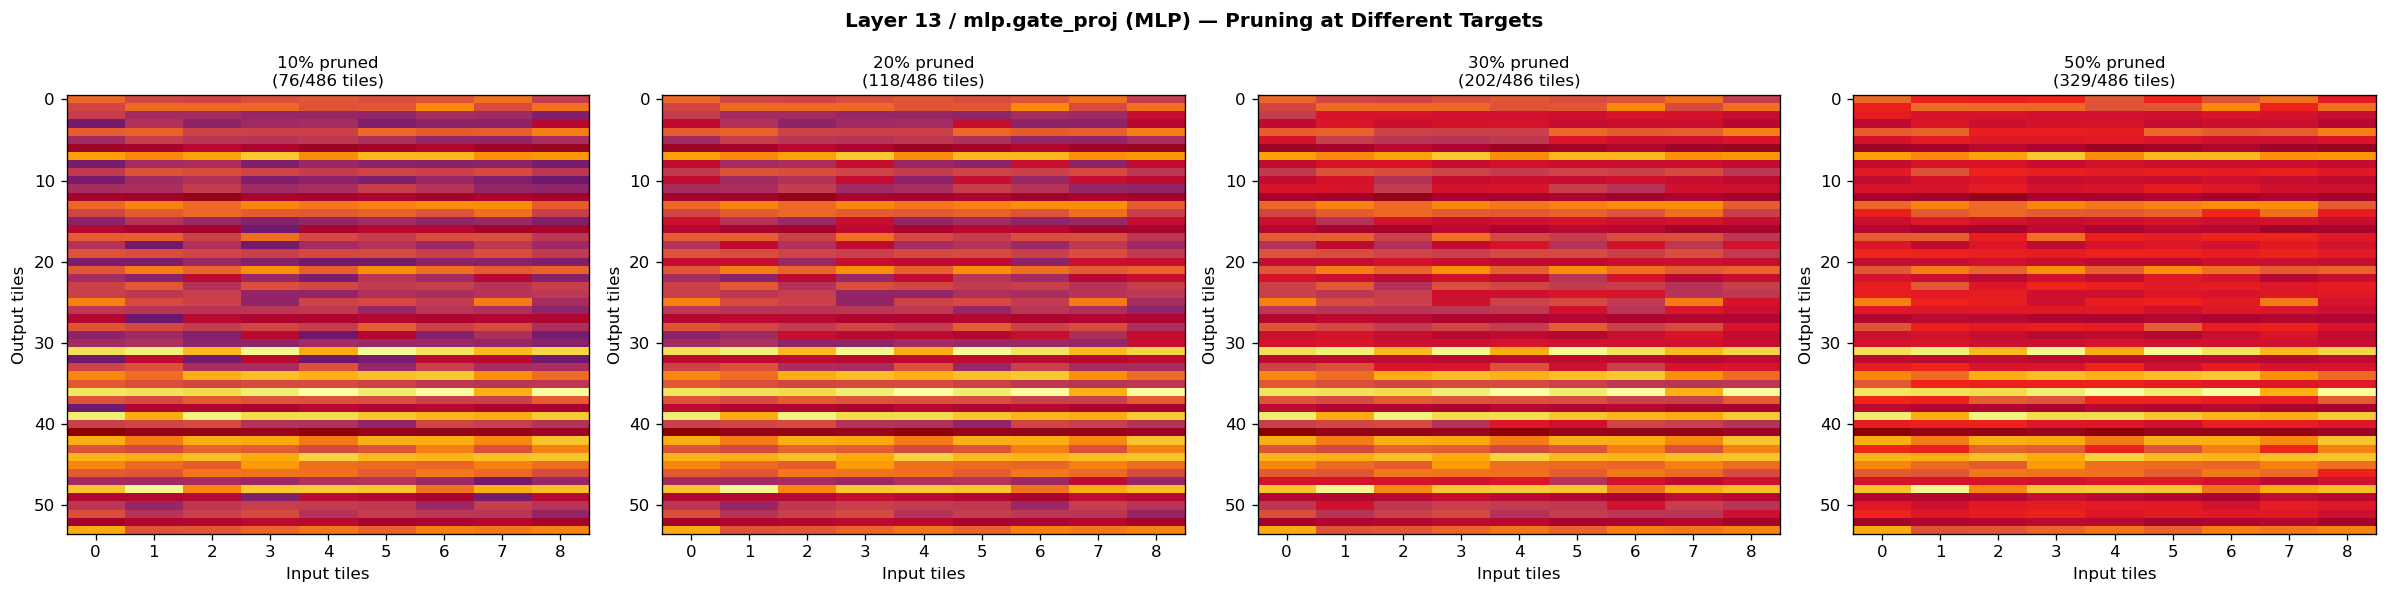

In [14]:
COMPARE_LAYER = n_layers // 2
mlp_comps = get_mlp_components(COMPARE_LAYER)
mlp_comps_n = get_mlp_components_norm(COMPARE_LAYER)
COMPARE_COMP = max(mlp_comps.keys(), key=lambda c: mlp_comps[c].size)

raw_map = mlp_comps[COMPARE_COMP]
norm_map = mlp_comps_n[COMPARE_COMP]
ratios = [0.10, 0.20, 0.30, 0.50]

fig, axes = plt.subplots(1, len(ratios), figsize=(5 * len(ratios), 5))

for ax, ratio in zip(axes, ratios):
    thresh = compute_global_threshold(importance_maps_mlp_norm, ratio)
    mask = norm_map < thresh
    
    ax.imshow(raw_map, aspect="auto", cmap="inferno", interpolation="nearest")
    overlay = np.zeros((*raw_map.shape, 4))
    overlay[mask] = [1, 0, 0, 0.55]
    ax.imshow(overlay, aspect="auto", interpolation="nearest")
    
    ax.set_title(f"{ratio*100:.0f}% pruned\n({mask.sum()}/{mask.size} tiles)", fontsize=10)
    ax.set_xlabel("Input tiles")
    ax.set_ylabel("Output tiles")

fig.suptitle(f"Layer {COMPARE_LAYER} / {COMPARE_COMP} (MLP) — Pruning at Different Targets",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

---

## 12. Sparsified Model Evaluation

Apply the pruning mask to the model (zero out the low-importance MLP tiles in-place), then run the same MMLU evaluation to measure the quality impact.

We test multiple pruning levels to build a tradeoff curve against the baseline (23.8%).

In [15]:
from eval_mmlu import evaluate, print_results, save_results

def get_capped_mask(norm_map: np.ndarray, threshold: float,
                    max_prune: float = config.MAX_PRUNE_PER_MATRIX) -> np.ndarray:
    """
    Compute pruning mask with a per-matrix safety cap.
    If the global threshold would prune more than max_prune fraction of this
    matrix's tiles, use a local threshold that caps at max_prune instead.
    """
    global_mask = norm_map < threshold
    if global_mask.mean() <= max_prune:
        return global_mask
    
    # Cap: only prune the bottom max_prune fraction of THIS matrix
    local_threshold = float(np.percentile(norm_map.ravel(), max_prune * 100))
    return norm_map < local_threshold

def apply_tile_pruning(model, importance_maps_norm: dict, threshold: float,
                       tile_r: int = TILE_R, tile_c: int = TILE_C):
    """
    Zero out tiles below the normalized threshold in the model's MLP weights,
    with a per-matrix cap to prevent catastrophic signal collapse.
    Modifies the model in-place.
    """
    total_pruned = 0
    total_tiles = 0
    capped_count = 0
    
    for name, param in model.named_parameters():
        if name not in importance_maps_norm:
            continue
        
        norm_map = importance_maps_norm[name]
        uncapped_ratio = (norm_map < threshold).mean()
        mask = get_capped_mask(norm_map, threshold)
        
        if uncapped_ratio > config.MAX_PRUNE_PER_MATRIX:
            capped_count += 1
        
        total_pruned += mask.sum()
        total_tiles += mask.size
        
        if not mask.any():
            continue
        
        with torch.no_grad():
            W = param.data
            n_rows, n_cols = norm_map.shape
            for ri in range(n_rows):
                for ci in range(n_cols):
                    if mask[ri, ci]:
                        r_start = ri * tile_r
                        r_end = r_start + tile_r
                        c_start = ci * tile_c
                        c_end = c_start + tile_c
                        W[r_start:r_end, c_start:c_end] = 0.0
    
    if capped_count > 0:
        print(f"  Cap applied to {capped_count} matrices (max {config.MAX_PRUNE_PER_MATRIX*100:.0f}% per matrix)")
    
    return total_pruned, total_tiles

def restore_model(model):
    """Reload original weights."""
    orig = AutoModelForCausalLM.from_pretrained(
        config.MODEL_NAME,
        torch_dtype=getattr(torch, config.TORCH_DTYPE),
        device_map=config.DEVICE,
    )
    with torch.no_grad():
        for (name, param), (_, orig_param) in zip(
            model.named_parameters(), orig.named_parameters()
        ):
            param.copy_(orig_param)
    del orig
    torch.cuda.empty_cache()

print(f"Pruning functions ready. Per-matrix cap: {config.MAX_PRUNE_PER_MATRIX*100:.0f}%")

Pruning functions ready. Per-matrix cap: 70%


In [16]:
import json, time
from pathlib import Path

# Pruning levels to test
EVAL_RATIOS = [0.10, 0.20, 0.30, 0.50]

# Load baseline results for comparison
baseline_path = Path(config.RESULTS_DIR) / "mmlu_baseline.json"
if baseline_path.exists():
    with open(baseline_path) as f:
        baseline_results = json.load(f)
    baseline_acc = baseline_results["overall"]["accuracy"]
    print(f"Baseline loaded: {baseline_acc*100:.1f}%")
else:
    print("WARNING: No baseline results found. Run run_baseline.py first.")
    baseline_acc = None

all_experiment_results = {}

for ratio in EVAL_RATIOS:
    print(f"\n{'='*60}")
    print(f"  Evaluating with {ratio*100:.0f}% MLP tile pruning")
    print(f"{'='*60}")
    
    # 1. Restore original weights
    print("Restoring original weights...")
    restore_model(model)
    
    # 2. Compute threshold and apply pruning
    thresh = compute_global_threshold(importance_maps_mlp_norm, ratio)
    pruned, total = apply_tile_pruning(model, importance_maps_mlp_norm, thresh)
    print(f"Pruned {pruned}/{total} MLP tiles ({pruned/total*100:.1f}%)")
    
    # 3. Evaluate
    t0 = time.time()
    tag = f"pruned_{int(ratio*100)}pct"
    results = evaluate(model, tokenizer, tag=tag)
    elapsed = time.time() - t0
    
    results["meta"] = {
        "prune_ratio": ratio,
        "tiles_pruned": int(pruned),
        "tiles_total": int(total),
        "eval_time_s": round(elapsed, 1),
    }
    
    print_results(results)
    save_results(results)
    all_experiment_results[ratio] = results

print("\nAll evaluations complete.")

Baseline loaded: 23.8%

  Evaluating with 10% MLP tile pruning
Restoring original weights...
  Cap applied to 2 matrices (max 70% per matrix)
Pruned 3657/37908 MLP tiles (9.6%)


[pruned_10pct] MMLU subjects: 100%|██████████████████████████████████| 10/10 [01:05<00:00,  6.57s/it]



  MMLU Results — pruned_10pct
  abstract_algebra               █████░░░░░░░░░░░░░░░  25.0% (25/100)
  anatomy                        ███░░░░░░░░░░░░░░░░░  17.8% (24/135)
  college_chemistry              ████░░░░░░░░░░░░░░░░  22.0% (22/100)
  college_computer_science       ██████░░░░░░░░░░░░░░  31.0% (31/100)
  econometrics                   ████░░░░░░░░░░░░░░░░  20.2% (23/114)
  global_facts                   ████░░░░░░░░░░░░░░░░  20.0% (20/100)
  machine_learning               █████░░░░░░░░░░░░░░░  26.8% (30/112)
  moral_scenarios                █████░░░░░░░░░░░░░░░  27.8% (249/895)
  professional_medicine          ███░░░░░░░░░░░░░░░░░  18.0% (49/272)
  us_foreign_policy              █████░░░░░░░░░░░░░░░  28.0% (28/100)
────────────────────────────────────────────────────────────
  OVERALL                                       24.7% (501/2028)

Results saved to results/mmlu_pruned_10pct.json

  Evaluating with 20% MLP tile pruning
Restoring original weights...
  Cap applied to 9 matr

[pruned_20pct] MMLU subjects: 100%|██████████████████████████████████| 10/10 [01:04<00:00,  6.46s/it]



  MMLU Results — pruned_20pct
  abstract_algebra               ████░░░░░░░░░░░░░░░░  22.0% (22/100)
  anatomy                        ████░░░░░░░░░░░░░░░░  23.7% (32/135)
  college_chemistry              ████░░░░░░░░░░░░░░░░  21.0% (21/100)
  college_computer_science       █████░░░░░░░░░░░░░░░  26.0% (26/100)
  econometrics                   ████░░░░░░░░░░░░░░░░  20.2% (23/114)
  global_facts                   ██████░░░░░░░░░░░░░░  30.0% (30/100)
  machine_learning               ██████░░░░░░░░░░░░░░  31.2% (35/112)
  moral_scenarios                █████░░░░░░░░░░░░░░░  27.2% (243/895)
  professional_medicine          █████░░░░░░░░░░░░░░░  26.1% (71/272)
  us_foreign_policy              █████░░░░░░░░░░░░░░░  26.0% (26/100)
────────────────────────────────────────────────────────────
  OVERALL                                       26.1% (529/2028)

Results saved to results/mmlu_pruned_20pct.json

  Evaluating with 30% MLP tile pruning
Restoring original weights...
  Cap applied to 19 mat

[pruned_30pct] MMLU subjects: 100%|██████████████████████████████████| 10/10 [01:05<00:00,  6.54s/it]



  MMLU Results — pruned_30pct
  abstract_algebra               ████░░░░░░░░░░░░░░░░  22.0% (22/100)
  anatomy                        █████░░░░░░░░░░░░░░░  25.2% (34/135)
  college_chemistry              █████░░░░░░░░░░░░░░░  25.0% (25/100)
  college_computer_science       █████░░░░░░░░░░░░░░░  27.0% (27/100)
  econometrics                   █████░░░░░░░░░░░░░░░  26.3% (30/114)
  global_facts                   ███░░░░░░░░░░░░░░░░░  18.0% (18/100)
  machine_learning               ██████░░░░░░░░░░░░░░  34.8% (39/112)
  moral_scenarios                ████░░░░░░░░░░░░░░░░  24.8% (222/895)
  professional_medicine          ████░░░░░░░░░░░░░░░░  21.3% (58/272)
  us_foreign_policy              █████░░░░░░░░░░░░░░░  26.0% (26/100)
────────────────────────────────────────────────────────────
  OVERALL                                       24.7% (501/2028)

Results saved to results/mmlu_pruned_30pct.json

  Evaluating with 50% MLP tile pruning
Restoring original weights...
  Cap applied to 34 mat

[pruned_50pct] MMLU subjects: 100%|██████████████████████████████████| 10/10 [01:05<00:00,  6.52s/it]


  MMLU Results — pruned_50pct
  abstract_algebra               ████░░░░░░░░░░░░░░░░  24.0% (24/100)
  anatomy                        ████░░░░░░░░░░░░░░░░  20.0% (27/135)
  college_chemistry              █████░░░░░░░░░░░░░░░  25.0% (25/100)
  college_computer_science       █████░░░░░░░░░░░░░░░  29.0% (29/100)
  econometrics                   ████░░░░░░░░░░░░░░░░  23.7% (27/114)
  global_facts                   █████░░░░░░░░░░░░░░░  28.0% (28/100)
  machine_learning               █████░░░░░░░░░░░░░░░  25.0% (28/112)
  moral_scenarios                █████░░░░░░░░░░░░░░░  26.3% (235/895)
  professional_medicine          ███░░░░░░░░░░░░░░░░░  19.5% (53/272)
  us_foreign_policy              ███░░░░░░░░░░░░░░░░░  19.0% (19/100)
────────────────────────────────────────────────────────────
  OVERALL                                       24.4% (495/2028)

Results saved to results/mmlu_pruned_50pct.json

All evaluations complete.


## 13. Results Comparison — Baseline vs Pruned

Variant                     Accuracy      Delta
-----------------------------------------------
Baseline (no pruning)          23.8%          —
Pruned 10%                     24.7%     +0.9pp
Pruned 20%                     26.1%     +2.3pp
Pruned 30%                     24.7%     +0.9pp
Pruned 50%                     24.4%     +0.6pp


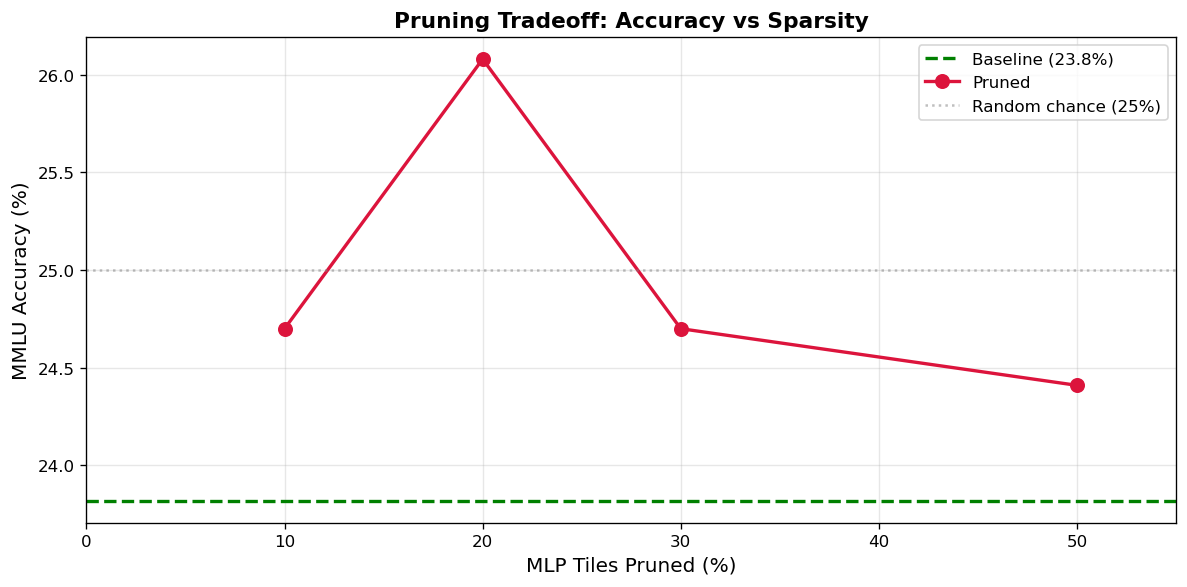

In [17]:
# Summary comparison table and tradeoff curve
ratios_tested = sorted(all_experiment_results.keys())
pruned_accs = [all_experiment_results[r]["overall"]["accuracy"] for r in ratios_tested]

print(f"{'Variant':<25s} {'Accuracy':>10s} {'Delta':>10s}")
print("-" * 47)
if baseline_acc is not None:
    print(f"{'Baseline (no pruning)':<25s} {baseline_acc*100:>9.1f}% {'—':>10s}")
for ratio, acc in zip(ratios_tested, pruned_accs):
    delta = (acc - baseline_acc) * 100 if baseline_acc else 0
    sign = "+" if delta >= 0 else ""
    print(f"{'Pruned ' + str(int(ratio*100)) + '%':<25s} {acc*100:>9.1f}% {sign + f'{delta:.1f}pp':>10s}")

# Tradeoff curve
fig, ax = plt.subplots(figsize=(10, 5))

if baseline_acc is not None:
    ax.axhline(baseline_acc * 100, color="green", linestyle="--", linewidth=2,
               label=f"Baseline ({baseline_acc*100:.1f}%)")

ax.plot([r * 100 for r in ratios_tested], [a * 100 for a in pruned_accs],
        "o-", color="crimson", linewidth=2, markersize=8, label="Pruned")

# Random chance line (25% for 4-choice MMLU)
ax.axhline(25.0, color="gray", linestyle=":", alpha=0.5, label="Random chance (25%)")

ax.set_xlabel("MLP Tiles Pruned (%)", fontsize=12)
ax.set_ylabel("MMLU Accuracy (%)", fontsize=12)
ax.set_title("Pruning Tradeoff: Accuracy vs Sparsity", fontweight="bold", fontsize=13)
ax.legend()
ax.set_xlim(0, 55)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()